### DIFFUSION\-BASED RECONSTRUCTION UNCERTAINTY FOR FETAL ULTRASOUND QUALITY\-GATED CLASSIFICATION

### GPU: L4/T4 sufficient \(inference\-heavy, minimal training\)

In [ ]:
# !pip install torch torchvision diffusers transformers accelerate scikit-learn pandas matplotlib seaborn tqdm gdown pillow numpy scipy

### Section 1: Imports and Setup

In [1]:
import os
import random
import warnings
import zipfile
import urllib.request
import shutil
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, f1_score
)
from sklearn.calibration import calibration_curve

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

import torchvision.transforms as T
from torchvision import models

from diffusers import DDPMScheduler, DDIMScheduler, UNet2DModel, DDPMPipeline

warnings.filterwarnings('ignore')

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

/root/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-18 04:18:58.756555: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766031538.771005     304 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766031538.775806     304 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766031538.789237     304 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:17660

### Section 2: Configuration

In [2]:
@dataclass
class Config:
    """Central configuration for the entire project."""
    
    # Paths
    csv_path: str = "/work/FETAL_PLANES_DB_data.csv"  # local CSV
    images_dir: str = "/tmp/fetal_data/Images"        # Downloaded images
    output_dir: str = "/work/outputs"                 # Persistent
    model_dir: str = "/work/models"                   # Persistent
    
    # Data parameters
    image_size: int = 256
    num_classes: int = 6
    class_names: List[str] = field(default_factory=lambda: [
        'Fetal abdomen', 'Fetal brain', 'Fetal femur', 
        'Fetal thorax', 'Maternal cervix', 'Other'
    ])
    
    # Training parameters
    batch_size: int = 16
    num_epochs: int = 15
    learning_rate: float = 3e-4
    weight_decay: float = 1e-4
    
    # Diffusion parameters (values reduced from original for faster results)
    ddpm_num_inference_steps: int = 20  # Was 50  # DDIM sampling for speed
    noise_levels: List[int] = field(default_factory=lambda: [400])  # Was [200, 400, 600]
    num_uncertainty_samples: int = 2  # Was 5  # Monte Carlo samples for variance
    
    # Deferral thresholds (calibrated during training)
    uncertainty_threshold: float = 0.15
    confidence_threshold: float = 0.6
    
    # Device
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    
    def __post_init__(self):
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(self.model_dir, exist_ok=True)

config = Config()
print(f"Using device: {config.device}")
print(f"Configuration loaded: {config.num_classes} classes, image size {config.image_size}")

Using device: cuda
Configuration loaded: 6 classes, image size 256


### Section 3: Data loading, preprocessing and visualisation

In [3]:
def download_and_extract_dataset():
    """Download dataset directly from Zenodo to /tmp."""
    DATA_DIR = "/tmp/fetal_data"
    IMAGES_DIR = "/tmp/fetal_data/Images"
    ZIP_PATH = "/tmp/FETAL_PLANES_ZENODO.zip"
    URL = "https://zenodo.org/records/3904280/files/FETAL_PLANES_ZENODO.zip?download=1"
    
    # Check if already extracted
    if os.path.exists(IMAGES_DIR) and len(os.listdir(IMAGES_DIR)) > 1000:
        num_images = len(os.listdir(IMAGES_DIR))
        print(f" Dataset already extracted! Found {num_images} images")
        return IMAGES_DIR
    
    os.makedirs(DATA_DIR, exist_ok=True)
    
    # Download
    print("=" * 60)
    print("DOWNLOADING DATASET FROM ZENODO")
    print("=" * 60)
    print(f"URL: {URL}")
    print("Size: ~2.5 GB | Estimated time: 3-5 minutes")
    print("Downloading", end="", flush=True)
    
    def progress_hook(count, block_size, total_size):
        if count % 100 == 0:
            print(".", end="", flush=True)
    
    urllib.request.urlretrieve(URL, ZIP_PATH, reporthook=progress_hook)
    print("\n Download complete!")
    
    # Extract
    print(" Extracting ZIP file...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print(" Extraction complete!")
    
    # Handle nested folder structure
    possible_image_paths = [
        "/tmp/fetal_data/Images",
        "/tmp/fetal_data/FETAL_PLANES_ZENODO/Images",
        "/tmp/fetal_data/FETAL_PLANES_DB/Images",
    ]
    
    for path in possible_image_paths:
        if os.path.exists(path) and len(os.listdir(path)) > 100:
            if path != IMAGES_DIR:
                shutil.move(path, IMAGES_DIR)
            break
    
    # Copy CSV if needed
    possible_csv_paths = [
        "/tmp/fetal_data/FETAL_PLANES_DB_data.csv",
        "/tmp/fetal_data/FETAL_PLANES_ZENODO/FETAL_PLANES_DB_data.csv",
        "/tmp/fetal_data/FETAL_PLANES_DB/FETAL_PLANES_DB_data.csv",
    ]
    
    work_csv = "/work/FETAL_PLANES_DB_data.csv"
    if not os.path.exists(work_csv):
        for csv_path in possible_csv_paths:
            if os.path.exists(csv_path):
                shutil.copy(csv_path, work_csv)
                print(f" Copied CSV to {work_csv}")
                break
    
    # Clean up ZIP
    if os.path.exists(ZIP_PATH):
        os.remove(ZIP_PATH)
        print(" Cleaned up ZIP file")
    
    num_images = len(os.listdir(IMAGES_DIR)) if os.path.exists(IMAGES_DIR) else 0
    print(f"\n Ready! {num_images} images in {IMAGES_DIR}")
    return IMAGES_DIR

class FetalPlanesDataset(Dataset):
    """PyTorch Dataset for FETAL_PLANES_DB."""
    
    def __init__(
        self,
        csv_path: str,
        images_dir: str,
        transform=None,
        split: str = 'train',
        val_ratio: float = 0.15,
        test_ratio: float = 0.15,
        seed: int = 42
    ):
        self.images_dir = Path(images_dir)
        self.transform = transform
        
        # Load CSV - try semicolon first (Zenodo format), then comma
        try:
            self.df = pd.read_csv(csv_path, sep=';')
            if len(self.df.columns) <= 1:
                self.df = pd.read_csv(csv_path, sep=',')
        except:
            self.df = pd.read_csv(csv_path, sep=',')
        
        print(f"CSV loaded: {len(self.df)} rows, columns: {list(self.df.columns)}")
        
        # Handle different column naming conventions
        if 'Image_name' not in self.df.columns:
            for col in self.df.columns:
                if 'image' in col.lower() or 'file' in col.lower():
                    self.df['Image_name'] = self.df[col]
                    break
        
        if 'Plane' not in self.df.columns:
            for col in self.df.columns:
                if 'plane' in col.lower() and 'brain' not in col.lower():
                    self.df['Plane'] = self.df[col]
                    break
        
        # Create label mapping
        unique_planes = sorted(self.df['Plane'].unique())
        self.label_map = {plane: idx for idx, plane in enumerate(unique_planes)}
        self.idx_to_label = {idx: plane for plane, idx in self.label_map.items()}
        
        print(f"Classes: {list(self.label_map.keys())}")
        
        # Stratified split by patient if available
        if 'Patient_num' in self.df.columns:
            patients = self.df['Patient_num'].unique()
            train_patients, temp_patients = train_test_split(
                patients, test_size=val_ratio + test_ratio, random_state=seed
            )
            val_patients, test_patients = train_test_split(
                temp_patients, test_size=test_ratio / (val_ratio + test_ratio), random_state=seed
            )
            
            if split == 'train':
                self.df = self.df[self.df['Patient_num'].isin(train_patients)]
            elif split == 'val':
                self.df = self.df[self.df['Patient_num'].isin(val_patients)]
            else:
                self.df = self.df[self.df['Patient_num'].isin(test_patients)]
        else:
            # Simple random split with stratification
            train_df, temp_df = train_test_split(
                self.df, test_size=val_ratio + test_ratio, 
                random_state=seed, stratify=self.df['Plane']
            )
            val_df, test_df = train_test_split(
                temp_df, test_size=test_ratio / (val_ratio + test_ratio), 
                random_state=seed, stratify=temp_df['Plane']
            )
            
            if split == 'train':
                self.df = train_df
            elif split == 'val':
                self.df = val_df
            else:
                self.df = test_df
        
        self.df = self.df.reset_index(drop=True)
        print(f"{split.capitalize()} set: {len(self.df)} images")
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['Image_name']
        
        # Add .png extension if missing
        if not img_name.endswith('.png'):
            img_name = img_name + '.png'
        
        img_path = self.images_dir / img_name
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Warning: Could not load {img_name}: {e}")
            image = Image.fromarray(np.random.randint(0, 255, (256, 256, 3), dtype=np.uint8))
        
        if self.transform:
            image = self.transform(image)
        
        label = self.label_map[row['Plane']]
        return image, label, img_name

def get_transforms(config: Config, is_training: bool = True):
    """Get image transforms for training and evaluation."""
    
    if is_training:
        return T.Compose([
            T.Resize((config.image_size, config.image_size)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.3),
            T.RandomRotation(15),
            T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    else:
        return T.Compose([
            T.Resize((config.image_size, config.image_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

def create_dataloaders(config: Config):
    """Create train, val, and test dataloaders."""
    print("\n" + "=" * 60)
    print("SETTING UP DATA")
    print("=" * 60)
    
    # Download and extract images from Zenodo
    images_dir = download_and_extract_dataset()
    
    # Verify CSV exists 
    if not os.path.exists(config.csv_path):
        print(f" CSV not found at {config.csv_path}")
        # Try alternative location from extracted ZIP
        alt_csv = "/tmp/fetal_data/FETAL_PLANES_DB/FETAL_PLANES_DB_data.csv"
        if os.path.exists(alt_csv):
            config.csv_path = alt_csv
            print(f" Using CSV from: {alt_csv}")
        else:
            raise FileNotFoundError("CSV file not found!")
    else:
        print(f" CSV found: {config.csv_path}")
    
    # Create datasets
    train_dataset = FetalPlanesDataset(
        csv_path=config.csv_path,
        images_dir=images_dir,
        transform=get_transforms(config, is_training=True),
        split='train'
    )
    
    val_dataset = FetalPlanesDataset(
        csv_path=config.csv_path,
        images_dir=images_dir,
        transform=get_transforms(config, is_training=False),
        split='val'
    )
    
    test_dataset = FetalPlanesDataset(
        csv_path=config.csv_path,
        images_dir=images_dir,
        transform=get_transforms(config, is_training=False),
        split='test'
    )
    
    # Update config with actual classes
    config.num_classes = len(train_dataset.label_map)
    config.class_names = list(train_dataset.label_map.keys())
    
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=2, pin_memory=True)
    
    print(f"\n DataLoaders ready!")
    print(f"   Train: {len(train_loader)} batches ({len(train_dataset)} images)")
    print(f"   Val: {len(val_loader)} batches ({len(val_dataset)} images)")
    print(f"   Test: {len(test_loader)} batches ({len(test_dataset)} images)")
    
    return train_loader, val_loader, test_loader, train_dataset.label_map, train_dataset.idx_to_label

In [4]:
def visualize_dataset(train_loader, val_loader, test_loader, label_map, config):
    """Visualize dataset statistics and sample images."""
    print("\n" + "=" * 60)
    print("DATA VISUALIZATION")
    print("=" * 60)
    
    idx_to_label = {v: k for k, v in label_map.items()}
    
    # 1. Class Distribution
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for ax, (loader, name) in zip(axes, [
        (train_loader, 'Train'),
        (val_loader, 'Validation'),
        (test_loader, 'Test')
    ]):
        # Count labels
        all_labels = []
        for _, labels, _ in loader:
            all_labels.extend(labels.numpy())
        
        # Count per class
        unique, counts = np.unique(all_labels, return_counts=True)
        class_names = [idx_to_label[i][:12] for i in unique]  # Truncate names
        
        bars = ax.bar(class_names, counts, color='steelblue', edgecolor='black')
        ax.set_title(f'{name} Set Distribution\n(n={len(all_labels)})')
        ax.set_xlabel('Class')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)
        
        # Add count labels on bars
        for bar, count in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                   str(count), ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.output_dir, 'class_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: class_distribution.png")
    
    # 2. Sample Images from Each Class
    num_classes = len(label_map)
    fig, axes = plt.subplots(2, num_classes, figsize=(18, 6))
    
    # Collect samples per class
    class_samples = {i: [] for i in range(num_classes)}
    
    for images, labels, filenames in train_loader:
        for img, label, fname in zip(images, labels, filenames):
            label_idx = label.item()
            if len(class_samples[label_idx]) < 2:  # Get 2 samples per class
                # Denormalize image
                mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                img_denorm = (img * std + mean).clamp(0, 1)
                class_samples[label_idx].append((img_denorm, fname))
        
        # Check if we have enough samples
        if all(len(v) >= 2 for v in class_samples.values()):
            break
    
    # Plot samples
    for class_idx in range(num_classes):
        class_name = idx_to_label[class_idx]
        for row in range(2):
            ax = axes[row, class_idx]
            if row < len(class_samples[class_idx]):
                img, fname = class_samples[class_idx][row]
                ax.imshow(img.permute(1, 2, 0).numpy())
                if row == 0:
                    ax.set_title(f'{class_name[:15]}', fontsize=10)
            ax.axis('off')
    
    plt.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(config.output_dir, 'sample_images.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: sample_images.png")
    
    # 3. Pixel Intensity Distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Collect pixel values from a subset of images
    all_pixels = []
    channel_means = {'R': [], 'G': [], 'B': []}
    
    for i, (images, _, _) in enumerate(train_loader):
        if i >= 10:  # Sample from 10 batches
            break
        
        # Denormalize
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        images_denorm = (images * std + mean).clamp(0, 1)
        
        for img in images_denorm:
            channel_means['R'].append(img[0].mean().item())
            channel_means['G'].append(img[1].mean().item())
            channel_means['B'].append(img[2].mean().item())
            all_pixels.extend(img.mean(dim=0).flatten().numpy())
    
    # Plot grayscale intensity distribution
    ax = axes[0]
    ax.hist(all_pixels, bins=50, color='gray', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Pixel Intensity (normalized)')
    ax.set_ylabel('Frequency')
    ax.set_title('Grayscale Intensity Distribution')
    ax.axvline(x=np.mean(all_pixels), color='red', linestyle='--', label=f'Mean: {np.mean(all_pixels):.3f}')
    ax.legend()
    
    # Plot per-channel mean distribution
    ax = axes[1]
    ax.hist(channel_means['R'], bins=30, alpha=0.5, color='red', label='Red')
    ax.hist(channel_means['G'], bins=30, alpha=0.5, color='green', label='Green')
    ax.hist(channel_means['B'], bins=30, alpha=0.5, color='blue', label='Blue')
    ax.set_xlabel('Channel Mean Intensity')
    ax.set_ylabel('Frequency')
    ax.set_title('Per-Channel Mean Distribution')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.output_dir, 'pixel_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: pixel_distribution.png")
    
    # 4. Dataset Summary Statistics
    print("\n" + "-" * 40)
    print("DATASET SUMMARY")
    print("-" * 40)
    
    train_size = len(train_loader.dataset)
    val_size = len(val_loader.dataset)
    test_size = len(test_loader.dataset)
    total_size = train_size + val_size + test_size
    
    print(f"Total images: {total_size}")
    print(f"  Train: {train_size} ({100*train_size/total_size:.1f}%)")
    print(f"  Val:   {val_size} ({100*val_size/total_size:.1f}%)")
    print(f"  Test:  {test_size} ({100*test_size/total_size:.1f}%)")
    print(f"\nNumber of classes: {num_classes}")
    print(f"Classes: {list(label_map.keys())}")
    print(f"Image size: {config.image_size}x{config.image_size}")
    print(f"Batch size: {config.batch_size}")
    
    return

### Section 4: Baseline classifier \(ResNet\-18\)

In [5]:
class FetalPlaneClassifier(nn.Module):
    """
    ResNet-18 based classifier for fetal plane classification.
    Uses transfer learning with ImageNet weights.
    """
    
    def __init__(self, num_classes: int, pretrained: bool = True):
        super().__init__()
        
        # Load pretrained ResNet-18
        self.backbone = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
        
        # Replace final FC layer
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        return self.backbone(x)
    
    def get_features(self, x):
        """Extract features before classification head."""
        # Forward through all layers except final fc
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        return x

def train_classifier(model, train_loader, val_loader, config: Config):
    """Train the baseline classifier."""
    print("\n" + "=" * 60)
    print("TRAINING BASELINE CLASSIFIER")
    print("=" * 60)
    
    model = model.to(config.device)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    scheduler = OneCycleLR(
        optimizer, max_lr=config.learning_rate * 10,
        epochs=config.num_epochs, steps_per_epoch=len(train_loader)
    )
    
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(config.num_epochs):
        # Training
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.num_epochs}")
        for images, labels, _ in pbar:
            images, labels = images.to(config.device), labels.to(config.device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*train_correct/train_total:.2f}%'})
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels, _ in val_loader:
                images, labels = images.to(config.device), labels.to(config.device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        # Record metrics
        train_acc = 100. * train_correct / train_total
        val_acc = 100. * val_correct / val_total
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}: Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), os.path.join(config.model_dir, 'best_classifier.pth'))
            print(f"  --> Saved new best model (Val Acc: {val_acc:.2f}%)")
    
    # Load best model
    model.load_state_dict(torch.load(os.path.join(config.model_dir, 'best_classifier.pth')))
    print(f"\nTraining complete. Best Val Accuracy: {best_val_acc:.2f}%")
    
    return model, history

### Section 5: Diffusion model for uncertainty estimation

In [6]:
class DiffusionUncertaintyEstimator:
    """
    Uses a pretrained diffusion model to estimate reconstruction uncertainty.
    
    Key insight: Images that are "unusual" or hard to reconstruct will have
    high variance across multiple reconstruction attempts.
    """
    
    def __init__(self, config: Config):
        self.config = config
        self.device = config.device
        
        print("\n" + "=" * 60)
        print("LOADING DIFFUSION MODEL")
        print("=" * 60)
        
        # Try to load pretrained fetal US diffusion model
        # Fallback to unconditional DDPM trained on similar medical images
        try:
            # Option 1: Try HuggingFace model
            self.pipeline = DDPMPipeline.from_pretrained(
                "google/ddpm-celebahq-256",  # Fallback model; substitute domain-specific model when available
                torch_dtype=torch.float32
            ).to(self.device)
            print("Loaded pretrained DDPM pipeline")
            
        except Exception as e:
            print(f"Could not load pretrained model: {e}")
            print("Creating custom UNet for diffusion...")
            self._create_custom_unet()
        
        # Setup scheduler for fast sampling
        self.scheduler = DDIMScheduler(
            num_train_timesteps=1000,
            beta_start=0.0001,
            beta_end=0.02,
            beta_schedule="linear",
            clip_sample=True
        )
        self.scheduler.set_timesteps(config.ddpm_num_inference_steps)
        
    def _create_custom_unet(self):
        """Create a simple UNet for reconstruction (when pretrained not available)."""
        self.unet = UNet2DModel(
            sample_size=256,
            in_channels=3,
            out_channels=3,
            layers_per_block=2,
            block_out_channels=(64, 128, 256, 256),
            down_block_types=(
                "DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D"
            ),
            up_block_types=(
                "UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D"
            ),
        ).to(self.device)
        
        self.pipeline = None  # Mark that we're using custom UNet
        print(f"Created custom UNet with {sum(p.numel() for p in self.unet.parameters()):,} parameters")
    
    @torch.no_grad()
    def add_noise(self, images: torch.Tensor, timestep: int) -> torch.Tensor:
        """Add noise to images at specified timestep."""
        noise = torch.randn_like(images)
        
        # Get scheduler parameters
        alpha_prod = self.scheduler.alphas_cumprod[timestep]
        sqrt_alpha_prod = alpha_prod ** 0.5
        sqrt_one_minus_alpha_prod = (1 - alpha_prod) ** 0.5
        
        noisy_images = sqrt_alpha_prod * images + sqrt_one_minus_alpha_prod * noise
        return noisy_images, noise
    
    @torch.no_grad()
    def denoise(self, noisy_images: torch.Tensor, start_timestep: int) -> torch.Tensor:
        """Denoise images from given timestep back to clean images."""
        images = noisy_images.clone()
        
        # Get timesteps from start_timestep
        timesteps = self.scheduler.timesteps[self.scheduler.timesteps <= start_timestep]
        
        for t in timesteps:
            t_batch = torch.tensor([t] * images.shape[0], device=self.device)
            
            if self.pipeline is not None:
                noise_pred = self.pipeline.unet(images, t_batch).sample
            else:
                noise_pred = self.unet(images, t_batch).sample
            
            images = self.scheduler.step(noise_pred, t, images).prev_sample
        
        return images.clamp(0, 1)
    
    @torch.no_grad()
    def compute_reconstruction_uncertainty(
        self, 
        images: torch.Tensor,
        noise_levels: List[int] = None,
        num_samples: int = None
    ) -> Dict[str, torch.Tensor]:
        """
        Compute reconstruction-based uncertainty for batch of images.
        
        Returns:
            - reconstruction_error: Mean L2 error across samples
            - reconstruction_variance: Variance of reconstructions (key uncertainty metric)
            - uncertainty_maps: Per-pixel uncertainty visualization
        """
        if noise_levels is None:
            noise_levels = self.config.noise_levels
        if num_samples is None:
            num_samples = self.config.num_uncertainty_samples
        
        images = images.to(self.device)
        batch_size = images.shape[0]
        
        all_reconstructions = []
        all_errors = []
        
        for noise_level in noise_levels:
            level_reconstructions = []
            
            for _ in range(num_samples):
                # Add noise and denoise
                noisy, _ = self.add_noise(images, noise_level)
                reconstructed = self.denoise(noisy, noise_level)
                
                level_reconstructions.append(reconstructed)
                
                # Compute per-image L2 error
                error = F.mse_loss(reconstructed, images, reduction='none')
                error = error.mean(dim=[1, 2, 3])  # Mean over C, H, W
                all_errors.append(error)
            
            all_reconstructions.append(torch.stack(level_reconstructions, dim=1))
        
        # Stack all reconstructions: [B, num_levels * num_samples, C, H, W]
        all_recons = torch.cat(all_reconstructions, dim=1)
        
        # Compute variance across all reconstructions (key uncertainty metric)
        reconstruction_variance = all_recons.var(dim=1).mean(dim=[1, 2, 3])
        
        # Mean reconstruction error
        reconstruction_error = torch.stack(all_errors, dim=1).mean(dim=1)
        
        # Per-pixel uncertainty map (for visualization)
        uncertainty_maps = all_recons.var(dim=1)  # [B, C, H, W]
        
        return {
            'reconstruction_error': reconstruction_error.cpu(),
            'reconstruction_variance': reconstruction_variance.cpu(),
            'uncertainty_maps': uncertainty_maps.cpu(),
            'mean_reconstruction': all_recons.mean(dim=1).cpu()
        }
    
    def compute_batch_uncertainty(
        self,
        dataloader: DataLoader,
        max_batches: int = None
    ) -> Tuple[np.ndarray, np.ndarray]:
        """Compute uncertainty for entire dataset."""
        all_variances = []
        all_errors = []
        
        print("Computing diffusion-based uncertainty...")
        
        for i, (images, labels, _) in enumerate(tqdm(dataloader)):
            if max_batches and i >= max_batches:
                break
            
            # Convert from ImageNet normalized to [0,1]
            mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
            images_01 = images * std + mean
            images_01 = images_01.clamp(0, 1)
            
            results = self.compute_reconstruction_uncertainty(images_01)
            all_variances.extend(results['reconstruction_variance'].numpy())
            all_errors.extend(results['reconstruction_error'].numpy())
        
        return np.array(all_variances), np.array(all_errors)

def load_or_compute_uncertainties(
    uncertainty_estimator: DiffusionUncertaintyEstimator,
    loader: DataLoader,
    save_path: str,
    name: str = ""
) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    """
    Load pre-computed uncertainties if available, otherwise compute and save.
    
    Args:
        uncertainty_estimator: DiffusionUncertaintyEstimator instance
        loader: DataLoader for the dataset
        save_path: Path to save/load uncertainties
        name: Name for logging (e.g., "validation", "test")
    
    Returns:
        Tuple of (uncertainties, errors) arrays. Errors is None if loaded from file.
    """
    if os.path.exists(save_path):
        print(f"Loading pre-computed {name} uncertainties from {save_path}")
        uncertainties = np.load(save_path)
        return uncertainties, None
    else:
        print(f"Computing {name} uncertainties (this may take a while)...")
        uncertainties, errors = uncertainty_estimator.compute_batch_uncertainty(loader)
        np.save(save_path, uncertainties)
        print(f"Saved {name} uncertainties to {save_path}")
        return uncertainties, errors

### Section 6: Quality\-gated deferral system

In [7]:
class QualityGatedClassifier:
    """
    Combines classifier predictions with diffusion uncertainty for 
    quality-aware classification with deferral capability.
    """
    
    def __init__(
        self, 
        classifier: nn.Module, 
        uncertainty_estimator: DiffusionUncertaintyEstimator,
        config: Config
    ):
        self.classifier = classifier
        self.uncertainty_estimator = uncertainty_estimator
        self.config = config
        self.device = config.device
        
        # Thresholds (to be calibrated)
        self.uncertainty_threshold = config.uncertainty_threshold
        self.confidence_threshold = config.confidence_threshold
        
    @torch.no_grad()
    def predict_with_uncertainty(
        self, 
        images: torch.Tensor,
        images_01: torch.Tensor = None
    ) -> Dict[str, torch.Tensor]:
        """
        Make predictions with uncertainty estimation.
        
        Returns dict with:
            - predictions: Predicted class indices
            - confidences: Softmax confidence scores
            - uncertainties: Diffusion-based uncertainty
            - should_defer: Boolean mask for deferral
        """
        self.classifier.eval()
        images = images.to(self.device)
        
        # Get classifier predictions
        logits = self.classifier(images)
        probs = F.softmax(logits, dim=1)
        confidences, predictions = probs.max(dim=1)
        
        # Get diffusion uncertainty
        if images_01 is None:
            mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(self.device)
            std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(self.device)
            images_01 = (images * std + mean).clamp(0, 1)
        
        uncertainty_results = self.uncertainty_estimator.compute_reconstruction_uncertainty(images_01)
        uncertainties = uncertainty_results['reconstruction_variance']
        
        # Deferral decision
        should_defer = (
            (uncertainties > self.uncertainty_threshold) | 
            (confidences.cpu() < self.confidence_threshold)
        )
        
        return {
            'predictions': predictions.cpu(),
            'confidences': confidences.cpu(),
            'uncertainties': uncertainties,
            'uncertainty_maps': uncertainty_results['uncertainty_maps'],
            'should_defer': should_defer,
            'logits': logits.cpu()
        }
    
    def calibrate_thresholds(
        self, 
        val_loader: DataLoader,
        target_coverage: float = 0.85,
        max_batches: int = 20
    ):
        """
        Calibrate deferral thresholds on validation set.
        Target: Achieve high accuracy on non-deferred samples while 
        maintaining target coverage (1 - deferral_rate).
        """
        print("\n" + "=" * 60)
        print("CALIBRATING DEFERRAL THRESHOLDS")
        print("=" * 60)
        
        all_confidences = []
        all_uncertainties = []
        all_correct = []
        all_labels = []
        all_preds = []
        
        self.classifier.eval()
        
        for i, (images, labels, _) in enumerate(tqdm(val_loader, desc="Calibrating")):
            if max_batches and i >= max_batches:
                break
            
            results = self.predict_with_uncertainty(images)
            
            correct = (results['predictions'] == labels).numpy()
            all_confidences.extend(results['confidences'].numpy())
            all_uncertainties.extend(results['uncertainties'].numpy())
            all_correct.extend(correct)
            all_labels.extend(labels.numpy())
            all_preds.extend(results['predictions'].numpy())
        
        all_confidences = np.array(all_confidences)
        all_uncertainties = np.array(all_uncertainties)
        all_correct = np.array(all_correct)
        
        # Find optimal thresholds using grid search
        best_acc_at_coverage = 0
        best_thresholds = (self.confidence_threshold, self.uncertainty_threshold)
        
        for conf_thresh in np.linspace(0.3, 0.95, 20):
            for unc_thresh in np.linspace(
                np.percentile(all_uncertainties, 50),
                np.percentile(all_uncertainties, 99),
                20
            ):
                # Compute deferral mask
                defer_mask = (all_uncertainties > unc_thresh) | (all_confidences < conf_thresh)
                coverage = 1 - defer_mask.mean()
                
                if coverage >= target_coverage - 0.05 and coverage <= target_coverage + 0.05:
                    # Accuracy on non-deferred
                    if (~defer_mask).sum() > 0:
                        acc = all_correct[~defer_mask].mean()
                        if acc > best_acc_at_coverage:
                            best_acc_at_coverage = acc
                            best_thresholds = (conf_thresh, unc_thresh)
        
        self.confidence_threshold, self.uncertainty_threshold = best_thresholds
        
        # Print calibration results
        defer_mask = (all_uncertainties > self.uncertainty_threshold) | \
                     (all_confidences < self.confidence_threshold)
        
        print(f"\nCalibrated Thresholds:")
        print(f"  Confidence threshold: {self.confidence_threshold:.3f}")
        print(f"  Uncertainty threshold: {self.uncertainty_threshold:.4f}")
        print(f"\nExpected Performance:")
        print(f"  Coverage: {100*(1-defer_mask.mean()):.1f}%")
        print(f"  Accuracy on non-deferred: {100*all_correct[~defer_mask].mean():.1f}%")
        print(f"  Overall accuracy: {100*all_correct.mean():.1f}%")
        
        return {
            'confidences': all_confidences,
            'uncertainties': all_uncertainties,
            'correct': all_correct,
            'labels': all_labels,
            'predictions': all_preds
        }

    def calibrate_thresholds_with_precomputed(
        self, 
        val_loader: DataLoader,
        precomputed_uncertainties: np.ndarray,
        target_coverage: float = 0.85
    ):
        """
        Calibrate deferral thresholds using pre-computed uncertainties.
        Much faster than computing uncertainties on-the-fly.
        """
        print("\n" + "=" * 60)
        print("CALIBRATING DEFERRAL THRESHOLDS")
        print("=" * 60)
        
        all_confidences = []
        all_correct = []
        all_labels = []
        all_preds = []
        
        self.classifier.eval()
        
        # Get classifier predictions only (uncertainties already computed)
        with torch.no_grad():
            for images, labels, _ in tqdm(val_loader, desc="Getting predictions"):
                images = images.to(self.device)
                logits = self.classifier(images)
                probs = F.softmax(logits, dim=1)
                confidences, predictions = probs.max(dim=1)
                
                correct = (predictions.cpu() == labels).numpy()
                all_confidences.extend(confidences.cpu().numpy())
                all_correct.extend(correct)
                all_labels.extend(labels.numpy())
                all_preds.extend(predictions.cpu().numpy())
        
        all_confidences = np.array(all_confidences)
        all_uncertainties = precomputed_uncertainties
        all_correct = np.array(all_correct)
        
        # Ensure lengths match
        min_len = min(len(all_confidences), len(all_uncertainties))
        all_confidences = all_confidences[:min_len]
        all_uncertainties = all_uncertainties[:min_len]
        all_correct = all_correct[:min_len]
        
        # Find optimal thresholds using grid search
        best_acc_at_coverage = 0
        best_thresholds = (self.confidence_threshold, self.uncertainty_threshold)
        
        for conf_thresh in np.linspace(0.3, 0.95, 20):
            for unc_thresh in np.linspace(
                np.percentile(all_uncertainties, 50),
                np.percentile(all_uncertainties, 99),
                20
            ):
                defer_mask = (all_uncertainties > unc_thresh) | (all_confidences < conf_thresh)
                coverage = 1 - defer_mask.mean()
                
                if coverage >= target_coverage - 0.05 and coverage <= target_coverage + 0.05:
                    if (~defer_mask).sum() > 0:
                        acc = all_correct[~defer_mask].mean()
                        if acc > best_acc_at_coverage:
                            best_acc_at_coverage = acc
                            best_thresholds = (conf_thresh, unc_thresh)
        
        self.confidence_threshold, self.uncertainty_threshold = best_thresholds
        
        # Print calibration results
        defer_mask = (all_uncertainties > self.uncertainty_threshold) | \
                    (all_confidences < self.confidence_threshold)
        
        print(f"\nCalibrated Thresholds:")
        print(f"  Confidence threshold: {self.confidence_threshold:.3f}")
        print(f"  Uncertainty threshold: {self.uncertainty_threshold:.4f}")
        print(f"\nExpected Performance:")
        print(f"  Coverage: {100*(1-defer_mask.mean()):.1f}%")
        print(f"  Accuracy on non-deferred: {100*all_correct[~defer_mask].mean():.1f}%")
        print(f"  Overall accuracy: {100*all_correct.mean():.1f}%")
        
        return {
            'confidences': all_confidences,
            'uncertainties': all_uncertainties,
            'correct': all_correct,
            'labels': all_labels,
            'predictions': all_preds
        }    

### Section 7: Evaluation and visualization 

In [8]:
def evaluate_deferral_system(
    gated_classifier: QualityGatedClassifier,
    test_loader: DataLoader,
    idx_to_label: Dict[int, str],
    config: Config
) -> Dict:
    """Comprehensive evaluation of the quality-gated classifier."""
    print("\n" + "=" * 60)
    print("EVALUATING DEFERRAL SYSTEM")
    print("=" * 60)
    
    all_results = {
        'predictions': [], 'labels': [], 'confidences': [],
        'uncertainties': [], 'should_defer': [], 'correct': []
    }
    
    for images, labels, _ in tqdm(test_loader, desc="Evaluating"):
        results = gated_classifier.predict_with_uncertainty(images)
        
        all_results['predictions'].extend(results['predictions'].numpy())
        all_results['labels'].extend(labels.numpy())
        all_results['confidences'].extend(results['confidences'].numpy())
        all_results['uncertainties'].extend(results['uncertainties'].numpy())
        all_results['should_defer'].extend(results['should_defer'].numpy())
        all_results['correct'].extend((results['predictions'] == labels).numpy())
    
    # Convert to numpy
    for k in all_results:
        all_results[k] = np.array(all_results[k])
    
    # Compute metrics
    defer_mask = all_results['should_defer']
    
    metrics = {
        'overall_accuracy': all_results['correct'].mean(),
        'deferral_rate': defer_mask.mean(),
        'coverage': 1 - defer_mask.mean(),
        'accuracy_on_non_deferred': all_results['correct'][~defer_mask].mean() if (~defer_mask).sum() > 0 else 0,
        'accuracy_on_deferred': all_results['correct'][defer_mask].mean() if defer_mask.sum() > 0 else 0,
    }
    
    print("\n" + "-" * 40)
    print("FINAL RESULTS")
    print("-" * 40)
    print(f"Overall Accuracy: {100*metrics['overall_accuracy']:.2f}%")
    print(f"Deferral Rate: {100*metrics['deferral_rate']:.2f}%")
    print(f"Coverage: {100*metrics['coverage']:.2f}%")
    print(f"Accuracy on Non-Deferred: {100*metrics['accuracy_on_non_deferred']:.2f}%")
    print(f"Accuracy on Deferred (would be): {100*metrics['accuracy_on_deferred']:.2f}%")
    print(f"\n--> Improvement from deferral: {100*(metrics['accuracy_on_non_deferred'] - metrics['overall_accuracy']):.2f}%")
    
    return all_results, metrics

def evaluate_deferral_system_with_precomputed(
    gated_classifier: QualityGatedClassifier,
    test_loader: DataLoader,
    precomputed_uncertainties: np.ndarray,
    idx_to_label: Dict[int, str],
    config: Config
) -> Dict:
    """Evaluate using pre-computed uncertainties (faster)."""
    print("\n" + "=" * 60)
    print("EVALUATING DEFERRAL SYSTEM")
    print("=" * 60)
    
    all_confidences = []
    all_predictions = []
    all_labels = []
    
    gated_classifier.classifier.eval()
    
    # Get classifier predictions only
    with torch.no_grad():
        for images, labels, _ in tqdm(test_loader, desc="Evaluating"):
            images = images.to(gated_classifier.device)
            logits = gated_classifier.classifier(images)
            probs = F.softmax(logits, dim=1)
            confidences, predictions = probs.max(dim=1)
            
            all_confidences.extend(confidences.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    all_confidences = np.array(all_confidences)
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_uncertainties = precomputed_uncertainties
    
    # Ensure lengths match
    min_len = min(len(all_confidences), len(all_uncertainties))
    all_confidences = all_confidences[:min_len]
    all_predictions = all_predictions[:min_len]
    all_labels = all_labels[:min_len]
    all_uncertainties = all_uncertainties[:min_len]
    
    # Compute correctness and deferral
    all_correct = (all_predictions == all_labels)
    should_defer = (
        (all_uncertainties > gated_classifier.uncertainty_threshold) | 
        (all_confidences < gated_classifier.confidence_threshold)
    )
    
    all_results = {
        'predictions': all_predictions,
        'labels': all_labels,
        'confidences': all_confidences,
        'uncertainties': all_uncertainties,
        'should_defer': should_defer,
        'correct': all_correct
    }
    
    # Compute metrics
    defer_mask = should_defer
    
    metrics = {
        'overall_accuracy': all_correct.mean(),
        'deferral_rate': defer_mask.mean(),
        'coverage': 1 - defer_mask.mean(),
        'accuracy_on_non_deferred': all_correct[~defer_mask].mean() if (~defer_mask).sum() > 0 else 0,
        'accuracy_on_deferred': all_correct[defer_mask].mean() if defer_mask.sum() > 0 else 0,
    }
    
    print("\n" + "-" * 40)
    print("FINAL RESULTS")
    print("-" * 40)
    print(f"Overall Accuracy: {100*metrics['overall_accuracy']:.2f}%")
    print(f"Deferral Rate: {100*metrics['deferral_rate']:.2f}%")
    print(f"Coverage: {100*metrics['coverage']:.2f}%")
    print(f"Accuracy on Non-Deferred: {100*metrics['accuracy_on_non_deferred']:.2f}%")
    print(f"Accuracy on Deferred (would be): {100*metrics['accuracy_on_deferred']:.2f}%")
    print(f"\n--> Improvement from deferral: {100*(metrics['accuracy_on_non_deferred'] - metrics['overall_accuracy']):.2f}%")
    
    return all_results, metrics

def plot_results(all_results: Dict, metrics: Dict, config: Config, gated_classifier: QualityGatedClassifier):
    """Generate comprehensive visualization of results."""
    print("\n" + "=" * 60)
    print("GENERATING VISUALIZATIONS")
    print("=" * 60)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 1. Coverage-Accuracy Curve
    ax = axes[0, 0]
    thresholds = np.percentile(all_results['uncertainties'], np.linspace(0, 100, 50))
    coverages, accuracies = [], []
    
    for thresh in thresholds:
        mask = all_results['uncertainties'] <= thresh
        if mask.sum() > 0:
            coverages.append(mask.mean())
            accuracies.append(all_results['correct'][mask].mean())
    
    ax.plot(coverages, accuracies, 'b-', linewidth=2)
    ax.axhline(y=metrics['overall_accuracy'], color='r', linestyle='--', label='Baseline')
    ax.set_xlabel('Coverage')
    ax.set_ylabel('Accuracy')
    ax.set_title('Coverage-Accuracy Curve')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Uncertainty Distribution
    ax = axes[0, 1]
    correct_unc = all_results['uncertainties'][all_results['correct'].astype(bool)]
    incorrect_unc = all_results['uncertainties'][~all_results['correct'].astype(bool)]
    
    ax.hist(correct_unc, bins=30, alpha=0.5, label='Correct', density=True)
    ax.hist(incorrect_unc, bins=30, alpha=0.5, label='Incorrect', density=True)
    ax.axvline(x=gated_classifier.uncertainty_threshold, color='r', linestyle='--', label='Threshold')
    ax.set_xlabel('Reconstruction Uncertainty')
    ax.set_ylabel('Density')
    ax.set_title('Uncertainty Distribution')
    ax.legend()
    
    # 3. Confidence vs Uncertainty Scatter
    ax = axes[0, 2]
    colors = ['green' if c else 'red' for c in all_results['correct']]
    ax.scatter(all_results['confidences'], all_results['uncertainties'], 
               c=colors, alpha=0.3, s=10)
    ax.axhline(y=config.uncertainty_threshold, color='blue', linestyle='--')
    ax.axvline(x=config.confidence_threshold, color='blue', linestyle='--')
    ax.set_xlabel('Softmax Confidence')
    ax.set_ylabel('Reconstruction Uncertainty')
    ax.set_title('Confidence vs Uncertainty\n(Green=Correct, Red=Incorrect)')
    
    # 4. Confusion Matrix (non-deferred only)
    ax = axes[1, 0]
    mask = ~all_results['should_defer']
    if mask.sum() > 0:
        cm = confusion_matrix(all_results['labels'][mask], all_results['predictions'][mask])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title('Confusion Matrix (Non-Deferred)')
    
    # 5. Calibration Curve
    ax = axes[1, 1]
    prob_true, prob_pred = calibration_curve(
        all_results['correct'], all_results['confidences'], n_bins=10
    )
    ax.plot(prob_pred, prob_true, 'o-', label='Model')
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
    ax.set_xlabel('Mean Predicted Confidence')
    ax.set_ylabel('Fraction Correct')
    ax.set_title('Calibration Curve')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. Summary Metrics Bar Chart
    ax = axes[1, 2]
    metric_names = ['Overall\nAccuracy', 'Non-Deferred\nAccuracy', 'Coverage']
    metric_values = [
        metrics['overall_accuracy'],
        metrics['accuracy_on_non_deferred'],
        metrics['coverage']
    ]
    bars = ax.bar(metric_names, metric_values, color=['blue', 'green', 'orange'])
    ax.set_ylim(0, 1)
    ax.set_ylabel('Value')
    ax.set_title('Summary Metrics', pad=15)
    
    for bar, val in zip(bars, metric_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{100*val:.1f}%', ha='center')
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.output_dir, 'results_summary.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved visualization to {config.output_dir}/results_summary.png")

def visualize_uncertainty_examples(
    gated_classifier: QualityGatedClassifier,
    test_loader: DataLoader,
    precomputed_uncertainties: np.ndarray,  
    idx_to_label: Dict[int, str],
    config: Config,
    num_examples: int = 8
):
    """Visualize examples with high and low uncertainty."""
    print("\nGenerating uncertainty visualization examples...")
    
    # Collect samples
    samples = {'images': [], 'labels': [], 'confidences': [], 'predictions': []}
    all_uncertainties = []
    
    gated_classifier.classifier.eval()
    idx = 0  # Track position in precomputed_uncertainties
    
    with torch.no_grad():
        for images, labels, _ in test_loader:
            batch_size = images.shape[0]
            
            # Get classifier predictions only (fast)
            images_device = images.to(gated_classifier.device)
            logits = gated_classifier.classifier(images_device)
            probs = F.softmax(logits, dim=1)
            confidences, predictions = probs.max(dim=1)
            
            # Denormalize images for visualization
            mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
            images_vis = (images * std + mean).clamp(0, 1)
            
            # Store results
            samples['images'].extend([img.cpu() for img in images_vis])
            samples['labels'].extend(labels.numpy())
            samples['confidences'].extend(confidences.cpu().numpy())
            samples['predictions'].extend(predictions.cpu().numpy())
            
            # Slice pre-computed uncertainties for this batch
            all_uncertainties.extend(precomputed_uncertainties[idx:idx + batch_size])
            idx += batch_size
            
            if len(samples['images']) >= 100:
                break
    
    # Convert to numpy
    all_uncertainties = np.array(all_uncertainties)
    all_confidences = np.array(samples['confidences'])
    all_preds = np.array(samples['predictions'])
    all_labels = np.array(samples['labels'])
    
    # Get high and low uncertainty indices
    high_unc_idx = np.argsort(all_uncertainties)[-num_examples//2:]
    low_unc_idx = np.argsort(all_uncertainties)[:num_examples//2]
    
    fig, axes = plt.subplots(2, num_examples//2, figsize=(15, 6))
    
    # Low uncertainty examples
    for i, idx in enumerate(low_unc_idx):
        ax = axes[0, i]
        img = samples['images'][idx].permute(1, 2, 0).numpy()
        ax.imshow(img)
        
        true_label = idx_to_label.get(samples['labels'][idx], str(samples['labels'][idx]))
        pred_label = idx_to_label.get(all_preds[idx], str(all_preds[idx]))
        correct = "✓" if samples['labels'][idx] == all_preds[idx] else "✗"
        
        ax.set_title(f'Low Unc: {all_uncertainties[idx]:.3f}\n'
                    f'Conf: {all_confidences[idx]:.2f} {correct}\n'
                    f'T:{true_label[:8]} P:{pred_label[:8]}', fontsize=8)
        ax.axis('off')
    
    # High uncertainty examples
    for i, idx in enumerate(high_unc_idx):
        ax = axes[1, i]
        img = samples['images'][idx].permute(1, 2, 0).numpy()
        ax.imshow(img)
        
        true_label = idx_to_label.get(samples['labels'][idx], str(samples['labels'][idx]))
        pred_label = idx_to_label.get(all_preds[idx], str(all_preds[idx]))
        correct = "✓" if samples['labels'][idx] == all_preds[idx] else "✗"
        defer = "DEFER" if all_uncertainties[idx] > config.uncertainty_threshold else ""
        
        ax.set_title(f'High Unc: {all_uncertainties[idx]:.3f} {defer}\n'
                    f'Conf: {all_confidences[idx]:.2f} {correct}\n'
                    f'T:{true_label[:8]} P:{pred_label[:8]}', fontsize=8)
        ax.axis('off')
    
    axes[0, 0].set_ylabel('Low Uncertainty', fontsize=12)
    axes[1, 0].set_ylabel('High Uncertainty', fontsize=12)
    
    plt.suptitle('Uncertainty Examples: Low (Top) vs High (Bottom)', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(config.output_dir, 'uncertainty_examples.png'), dpi=150, bbox_inches='tight')
    plt.show()

### Section 8: Extended Analysis and Ablation Studies

In [9]:
# 8.1 COMPARISON WITH OTHER UNCERTAINTY METHODS
class MCDropoutUncertainty:
    """Monte Carlo Dropout for uncertainty estimation (baseline comparison)."""
    
    def __init__(self, model, num_samples=10, dropout_rate=0.3):
        self.model = model
        self.num_samples = num_samples
        self.dropout_rate = dropout_rate
        
    def enable_dropout(self):
        """Enable dropout during inference."""
        for module in self.model.modules():
            if isinstance(module, nn.Dropout):
                module.train()
    
    @torch.no_grad()
    def predict_with_uncertainty(self, images, device):
        """Get predictions with MC Dropout uncertainty."""
        self.model.eval()
        self.enable_dropout()
        
        images = images.to(device)
        all_probs = []
        
        for _ in range(self.num_samples):
            logits = self.model(images)
            probs = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu())
        
        all_probs = torch.stack(all_probs, dim=0)  # [num_samples, batch, classes]
        
        # Mean prediction
        mean_probs = all_probs.mean(dim=0)
        predictions = mean_probs.argmax(dim=1)
        confidences = mean_probs.max(dim=1).values
        
        # Uncertainty = variance of predictions
        uncertainty = all_probs.var(dim=0).mean(dim=1)  # Average variance across classes
        
        return {
            'predictions': predictions,
            'confidences': confidences,
            'uncertainties': uncertainty.numpy()
        }


class DeepEnsembleUncertainty:
    """Simple ensemble uncertainty using augmentation (pseudo-ensemble)."""
    
    def __init__(self, model, num_augmentations=5):
        self.model = model
        self.num_augmentations = num_augmentations
        self.augment = T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(10),
            T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        ])
    
    @torch.no_grad()
    def predict_with_uncertainty(self, images, device):
        """Get predictions with augmentation-based uncertainty."""
        self.model.eval()
        images = images.to(device)
        
        all_probs = []
        
        # Original prediction
        logits = self.model(images)
        all_probs.append(F.softmax(logits, dim=1).cpu())
        
        # Augmented predictions
        for _ in range(self.num_augmentations - 1):
            aug_images = torch.stack([self.augment(img.cpu()) for img in images]).to(device)
            logits = self.model(aug_images)
            all_probs.append(F.softmax(logits, dim=1).cpu())
        
        all_probs = torch.stack(all_probs, dim=0)
        
        mean_probs = all_probs.mean(dim=0)
        predictions = mean_probs.argmax(dim=1)
        confidences = mean_probs.max(dim=1).values
        uncertainty = all_probs.var(dim=0).mean(dim=1)
        
        return {
            'predictions': predictions,
            'confidences': confidences,
            'uncertainties': uncertainty.numpy()
        }


def compare_uncertainty_methods(
    classifier, 
    gated_classifier,
    test_loader, 
    test_uncertainties,
    config
):
    """Compare diffusion-based uncertainty with other methods."""
    print("\n" + "=" * 60)
    print("COMPARING UNCERTAINTY METHODS")
    print("=" * 60)
    
    device = config.device
    
    # Initialize other methods
    mc_dropout = MCDropoutUncertainty(classifier, num_samples=10)
    ensemble = DeepEnsembleUncertainty(classifier, num_augmentations=5)
    
    # Collect results
    methods = {
        'Diffusion': {'uncertainties': [], 'correct': []},
        'MC Dropout': {'uncertainties': [], 'correct': []},
        'Augmentation Ensemble': {'uncertainties': [], 'correct': []},
        'Softmax Confidence': {'uncertainties': [], 'correct': []}
    }
    
    all_labels = []
    diffusion_idx = 0
    
    for images, labels, _ in tqdm(test_loader, desc="Comparing methods"):
        batch_size = images.shape[0]
        all_labels.extend(labels.numpy())
        
        # Diffusion (pre-computed)
        batch_diff_unc = test_uncertainties[diffusion_idx:diffusion_idx + batch_size]
        diffusion_idx += batch_size
        
        # MC Dropout
        mc_results = mc_dropout.predict_with_uncertainty(images, device)
        
        # Ensemble
        ens_results = ensemble.predict_with_uncertainty(images, device)
        
        # Softmax confidence (1 - confidence as uncertainty)
        classifier.eval()
        with torch.no_grad():
            logits = classifier(images.to(device))
            probs = F.softmax(logits, dim=1)
            softmax_conf, softmax_preds = probs.max(dim=1)
            softmax_unc = (1 - softmax_conf).cpu().numpy()
        
        # Store results
        correct = (softmax_preds.cpu() == labels).numpy()
        
        methods['Diffusion']['uncertainties'].extend(batch_diff_unc)
        methods['Diffusion']['correct'].extend(correct)
        
        methods['MC Dropout']['uncertainties'].extend(mc_results['uncertainties'])
        methods['MC Dropout']['correct'].extend((mc_results['predictions'] == labels).numpy())
        
        methods['Augmentation Ensemble']['uncertainties'].extend(ens_results['uncertainties'])
        methods['Augmentation Ensemble']['correct'].extend((ens_results['predictions'] == labels).numpy())
        
        methods['Softmax Confidence']['uncertainties'].extend(softmax_unc)
        methods['Softmax Confidence']['correct'].extend(correct)
    
    # Convert to numpy
    for method in methods:
        methods[method]['uncertainties'] = np.array(methods[method]['uncertainties'])
        methods[method]['correct'] = np.array(methods[method]['correct'])
    
    # Plot comparison
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Coverage-Accuracy curves for all methods
    ax = axes[0, 0]
    colors = ['blue', 'red', 'green', 'orange']
    
    for (method_name, data), color in zip(methods.items(), colors):
        uncertainties = data['uncertainties']
        correct = data['correct']
        
        thresholds = np.percentile(uncertainties, np.linspace(0, 100, 50))
        coverages, accuracies = [], []
        
        for thresh in thresholds:
            mask = uncertainties <= thresh
            if mask.sum() > 0:
                coverages.append(mask.mean())
                accuracies.append(correct[mask].mean())
        
        ax.plot(coverages, accuracies, '-', color=color, linewidth=2, label=method_name)
    
    ax.set_xlabel('Coverage')
    ax.set_ylabel('Accuracy')
    ax.set_title('Coverage-Accuracy Curves by Method')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Uncertainty distributions (correct vs incorrect)
    ax = axes[0, 1]
    x_positions = np.arange(len(methods))
    width = 0.35
    
    correct_means = []
    incorrect_means = []
    
    for method_name, data in methods.items():
        correct_mask = data['correct'].astype(bool)
        correct_means.append(data['uncertainties'][correct_mask].mean())
        incorrect_means.append(data['uncertainties'][~correct_mask].mean())
    
    ax.bar(x_positions - width/2, correct_means, width, label='Correct', color='green', alpha=0.7)
    ax.bar(x_positions + width/2, incorrect_means, width, label='Incorrect', color='red', alpha=0.7)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([m[:10] for m in methods.keys()], rotation=45, ha='right')
    ax.set_ylabel('Mean Uncertainty')
    ax.set_title('Uncertainty: Correct vs Incorrect Predictions')
    ax.legend()
    
    # 3. AUC-ROC for error detection
    ax = axes[1, 0]
    aucs = []
    
    for method_name, data in methods.items():
        # Higher uncertainty should predict errors (incorrect predictions)
        method_errors = (~data['correct']).astype(int)
        fpr, tpr, _ = roc_curve(method_errors, data['uncertainties'])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
    
    bars = ax.bar(list(methods.keys()), aucs, color=colors, alpha=0.7, edgecolor='black')
    ax.set_ylabel('AUC-ROC')
    ax.set_title('Error Detection AUC (Higher = Better)')
    ax.set_ylim(0.5, 1.0)
    ax.axhline(y=0.5, color='gray', linestyle='--', label='Random')
    
    for bar, auc_val in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
               f'{auc_val:.3f}', ha='center', va='bottom', fontsize=10)
    
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(list(methods.keys()), rotation=30, ha='right', fontsize=9)

    # 4. Summary table
    ax = axes[1, 1]
    ax.axis('off')
    
    # Compute metrics at 85% coverage
    table_data = []
    for method_name, data in methods.items():
        uncertainties = data['uncertainties']
        correct = data['correct']
        
        # Find threshold for 85% coverage
        thresh = np.percentile(uncertainties, 85)
        mask = uncertainties <= thresh
        
        if mask.sum() > 0:
            acc_at_85 = correct[mask].mean()
        else:
            acc_at_85 = 0
        
        # Error detection AUC
        prediction_errors = (~correct).astype(int)
        fpr, tpr, _ = roc_curve(prediction_errors, uncertainties)
        error_auc = auc(fpr, tpr)
        
        table_data.append([method_name[:15], f'{100*acc_at_85:.1f}%', f'{error_auc:.3f}'])
    
    table = ax.table(
        cellText=table_data,
        colLabels=['Method', 'Acc@85% Cov', 'Error AUC'],
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.5)
    ax.set_title('Summary Metrics', fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.output_dir, 'uncertainty_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: uncertainty_comparison.png")
    
    return methods

# 8.2 PER-CLASS DEFERRAL ANALYSIS
def per_class_analysis(test_results, idx_to_label, config):
    """Analyze deferral performance per class."""
    print("\n" + "=" * 60)
    print("PER-CLASS DEFERRAL ANALYSIS")
    print("=" * 60)
    
    labels = test_results['labels']
    predictions = test_results['predictions']
    uncertainties = test_results['uncertainties']
    correct = test_results['correct']
    should_defer = test_results['should_defer']
    
    num_classes = len(idx_to_label)
    
    # Compute per-class metrics
    class_metrics = {}
    
    for class_idx in range(num_classes):
        class_name = idx_to_label[class_idx]
        mask = labels == class_idx
        
        if mask.sum() == 0:
            continue
        
        class_correct = correct[mask]
        class_defer = should_defer[mask]
        class_unc = uncertainties[mask]
        
        non_defer_mask = ~class_defer
        
        class_metrics[class_name] = {
            'total': mask.sum(),
            'overall_acc': class_correct.mean(),
            'deferral_rate': class_defer.mean(),
            'acc_non_deferred': class_correct[non_defer_mask].mean() if non_defer_mask.sum() > 0 else 0,
            'mean_uncertainty': class_unc.mean(),
            'improvement': (class_correct[non_defer_mask].mean() - class_correct.mean()) if non_defer_mask.sum() > 0 else 0
        }
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    class_names = list(class_metrics.keys())
    short_names = [name[:12] for name in class_names]
    
    # 1. Overall vs Non-deferred accuracy
    ax = axes[0, 0]
    x = np.arange(len(class_names))
    width = 0.35
    
    overall_accs = [class_metrics[c]['overall_acc'] for c in class_names]
    nondefer_accs = [class_metrics[c]['acc_non_deferred'] for c in class_names]
    
    ax.bar(x - width/2, overall_accs, width, label='Overall', color='blue', alpha=0.7)
    ax.bar(x + width/2, nondefer_accs, width, label='Non-Deferred', color='green', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=45, ha='right')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy by Class: Overall vs Non-Deferred')
    ax.legend()
    ax.set_ylim(0, 1.1)
    
    # 2. Deferral rate per class
    ax = axes[0, 1]
    deferral_rates = [class_metrics[c]['deferral_rate'] for c in class_names]
    colors = plt.cm.Reds(np.array(deferral_rates) / max(deferral_rates) * 0.7 + 0.3)
    
    bars = ax.bar(short_names, deferral_rates, color=colors, edgecolor='black')
    ax.set_ylabel('Deferral Rate')
    ax.set_title('Deferral Rate by Class')
    ax.set_ylim(0, max(deferral_rates) * 1.2)
    plt.xticks(rotation=45, ha='right')
    
    for bar, rate in zip(bars, deferral_rates):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
               f'{100*rate:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # 3. Mean uncertainty per class
    ax = axes[1, 0]
    mean_uncs = [class_metrics[c]['mean_uncertainty'] for c in class_names]
    colors = plt.cm.Blues(np.array(mean_uncs) / max(mean_uncs) * 0.7 + 0.3)
    
    bars = ax.bar(short_names, mean_uncs, color=colors, edgecolor='black')
    ax.set_ylabel('Mean Uncertainty')
    ax.set_title('Mean Uncertainty by Class')
    plt.xticks(rotation=45, ha='right')
    
    # 4. Improvement from deferral
    ax = axes[1, 1]
    improvements = [class_metrics[c]['improvement'] * 100 for c in class_names]
    colors = ['green' if imp > 0 else 'red' for imp in improvements]
    
    bars = ax.bar(short_names, improvements, color=colors, alpha=0.7, edgecolor='black')
    ax.set_ylabel('Accuracy Improvement (%)')
    ax.set_title('Improvement from Deferral by Class')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    plt.xticks(rotation=45, ha='right')
    
    for bar, imp in zip(bars, improvements):
        y_pos = bar.get_height() + 0.5 if bar.get_height() >= 0 else bar.get_height() - 1.5
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
               f'{imp:.1f}%', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.output_dir, 'per_class_analysis.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: per_class_analysis.png")
    
    # Print summary table
    print("\n" + "-" * 70)
    print(f"{'Class':<20} {'Total':<8} {'Acc':<8} {'NonDef Acc':<12} {'Defer %':<10} {'Improv':<8}")
    print("-" * 70)
    for class_name, m in class_metrics.items():
        print(f"{class_name:<20} {m['total']:<8} {100*m['overall_acc']:.1f}%    "
              f"{100*m['acc_non_deferred']:.1f}%        {100*m['deferral_rate']:.1f}%      "
              f"{100*m['improvement']:+.1f}%")
    
    return class_metrics

# 8.3 ABLATION STUDY ON DIFFUSION PARAMETERS
def ablation_study(uncertainty_estimator, test_loader, config, max_batches=10):
    """Ablation study on diffusion parameters."""
    print("\n" + "=" * 60)
    print("ABLATION STUDY: DIFFUSION PARAMETERS")
    print("=" * 60)
    
    # Collect a subset of images
    all_images = []
    all_labels = []
    
    for i, (images, labels, _) in enumerate(test_loader):
        if i >= max_batches:
            break
        # Denormalize
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        images_01 = (images * std + mean).clamp(0, 1)
        all_images.append(images_01)
        all_labels.extend(labels.numpy())
    
    all_images = torch.cat(all_images, dim=0)
    all_labels = np.array(all_labels)
    
    print(f"Running ablation on {len(all_images)} images...")
    
    # Test different configurations
    ablation_configs = [
        {'noise_levels': [200], 'num_samples': 3, 'name': '1 level, 3 samples'},
        {'noise_levels': [400], 'num_samples': 3, 'name': '1 level (mid), 3 samples'},
        {'noise_levels': [200, 400], 'num_samples': 3, 'name': '2 levels, 3 samples'},
        {'noise_levels': [200, 400, 600], 'num_samples': 3, 'name': '3 levels, 3 samples'},
        {'noise_levels': [200, 400, 600], 'num_samples': 5, 'name': '3 levels, 5 samples'},
        {'noise_levels': [200, 400, 600], 'num_samples': 10, 'name': '3 levels, 10 samples'},
    ]
    
    results = []
    
    for cfg in tqdm(ablation_configs, desc="Ablation configs"):
        uncertainties = []
        
        # Process in batches
        batch_size = 8
        for i in range(0, len(all_images), batch_size):
            batch = all_images[i:i+batch_size]
            result = uncertainty_estimator.compute_reconstruction_uncertainty(
                batch,
                noise_levels=cfg['noise_levels'],
                num_samples=cfg['num_samples']
            )
            uncertainties.extend(result['reconstruction_variance'].numpy())
        
        uncertainties = np.array(uncertainties)
        
        results.append({
            'name': cfg['name'],
            'noise_levels': cfg['noise_levels'],
            'num_samples': cfg['num_samples'],
            'mean_unc': uncertainties.mean(),
            'std_unc': uncertainties.std(),
            'uncertainties': uncertainties
        })
    
    # Plot results
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Uncertainty statistics
    ax = axes[0]
    names = [r['name'] for r in results]
    means = [r['mean_unc'] for r in results]
    stds = [r['std_unc'] for r in results]
    
    x = np.arange(len(names))
    ax.bar(x, means, yerr=stds, capsize=5, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_ylabel('Mean Uncertainty')
    ax.set_title('Uncertainty by Configuration')
    
    # 2. Correlation between configurations
    ax = axes[1]
    
    # Compare first vs last config
    ax.scatter(results[0]['uncertainties'], results[-1]['uncertainties'], alpha=0.5, s=20)
    ax.set_xlabel(f"Uncertainty: {results[0]['name']}")
    ax.set_ylabel(f"Uncertainty: {results[-1]['name']}")
    
    # Compute correlation
    corr = np.corrcoef(results[0]['uncertainties'], results[-1]['uncertainties'])[0, 1]
    ax.set_title(f'Correlation Between Configs (r={corr:.3f})')
    
    # Add diagonal line
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'r--', alpha=0.5, label='y=x')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.output_dir, 'ablation_study.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: ablation_study.png")
    
    # Print summary
    print("\n" + "-" * 60)
    print(f"{'Configuration':<30} {'Mean Unc':<12} {'Std Unc':<12}")
    print("-" * 60)
    for r in results:
        print(f"{r['name']:<30} {r['mean_unc']:.4f}       {r['std_unc']:.4f}")
    
    return results

# 8.4 FEATURE SPACE VISUALIZATION (t-SNE)
def visualize_feature_space(classifier, test_loader, test_uncertainties, idx_to_label, config, max_samples=1000):
    """Visualize feature space with t-SNE, colored by class and uncertainty."""
    print("\n" + "=" * 60)
    print("FEATURE SPACE VISUALIZATION (t-SNE)")
    print("=" * 60)
    
    from sklearn.manifold import TSNE
    
    classifier.eval()
    all_features = []
    all_labels = []
    all_correct = []
    sample_count = 0
    
    with torch.no_grad():
        for images, labels, _ in tqdm(test_loader, desc="Extracting features"):
            if sample_count >= max_samples:
                break
            
            images = images.to(config.device)
            features = classifier.get_features(images)
            
            # Get predictions
            logits = classifier(images)
            preds = logits.argmax(dim=1)
            correct = (preds.cpu() == labels).numpy()
            
            all_features.append(features.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_correct.extend(correct)
            sample_count += len(labels)
    
    all_features = np.concatenate(all_features, axis=0)[:max_samples]
    all_labels = np.array(all_labels)[:max_samples]
    all_correct = np.array(all_correct)[:max_samples]
    uncertainties = test_uncertainties[:max_samples]
    
    print(f"Running t-SNE on {len(all_features)} samples...")
    
    # Run t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    features_2d = tsne.fit_transform(all_features)
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Colored by class
    ax = axes[0]
    num_classes = len(idx_to_label)
    colors = plt.cm.tab10(np.linspace(0, 1, num_classes))
    
    for class_idx in range(num_classes):
        mask = all_labels == class_idx
        ax.scatter(features_2d[mask, 0], features_2d[mask, 1],
                  c=[colors[class_idx]], label=idx_to_label[class_idx][:12],
                  alpha=0.6, s=20)
    
    ax.set_title('Feature Space by Class')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # 2. Colored by uncertainty
    ax = axes[1]
    scatter = ax.scatter(features_2d[:, 0], features_2d[:, 1],
                        c=uncertainties, cmap='Reds', alpha=0.6, s=20)
    plt.colorbar(scatter, ax=ax, label='Uncertainty')
    ax.set_title('Feature Space by Uncertainty')
    ax.set_xticks([])
    ax.set_yticks([])
    
    # 3. Colored by correct/incorrect
    ax = axes[2]
    colors = ['green' if c else 'red' for c in all_correct]
    ax.scatter(features_2d[:, 0], features_2d[:, 1], c=colors, alpha=0.6, s=20)
    ax.scatter([], [], c='green', label='Correct')
    ax.scatter([], [], c='red', label='Incorrect')
    ax.set_title('Feature Space: Correct vs Incorrect')
    ax.legend()
    ax.set_xticks([])
    ax.set_yticks([])
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.output_dir, 'feature_space_tsne.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: feature_space_tsne.png")

# 8.5 CLINICAL METRICS (SENSITIVITY / SPECIFICITY)
def clinical_metrics_analysis(test_results, idx_to_label, config):
    """Compute clinical metrics at various deferral rates."""
    print("\n" + "=" * 60)
    print("CLINICAL METRICS ANALYSIS")
    print("=" * 60)
    
    labels = test_results['labels']
    predictions = test_results['predictions']
    uncertainties = test_results['uncertainties']
    
    num_classes = len(idx_to_label)
    
    # Compute metrics at different coverage levels
    coverage_levels = [1.0, 0.95, 0.90, 0.85, 0.80, 0.75]
    
    results = []
    
    for coverage in coverage_levels:
        # Find threshold for this coverage
        if coverage < 1.0:
            thresh = np.percentile(uncertainties, coverage * 100)
            mask = uncertainties <= thresh
        else:
            mask = np.ones(len(labels), dtype=bool)
        
        actual_coverage = mask.mean()
        
        # Compute per-class sensitivity and specificity
        class_metrics = {}
        
        for class_idx in range(num_classes):
            class_name = idx_to_label[class_idx]
            
            # Binary classification: this class vs all others
            y_true = (labels[mask] == class_idx).astype(int)
            y_pred = (predictions[mask] == class_idx).astype(int)
            
            # True positives, false positives, etc.
            tp = ((y_true == 1) & (y_pred == 1)).sum()
            tn = ((y_true == 0) & (y_pred == 0)).sum()
            fp = ((y_true == 0) & (y_pred == 1)).sum()
            fn = ((y_true == 1) & (y_pred == 0)).sum()
            
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precision
            npv = tn / (tn + fn) if (tn + fn) > 0 else 0
            
            class_metrics[class_name] = {
                'sensitivity': sensitivity,
                'specificity': specificity,
                'ppv': ppv,
                'npv': npv
            }
        
        # Overall accuracy
        accuracy = (predictions[mask] == labels[mask]).mean()
        
        results.append({
            'target_coverage': coverage,
            'actual_coverage': actual_coverage,
            'accuracy': accuracy,
            'class_metrics': class_metrics
        })
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Sensitivity by class at different coverage levels
    ax = axes[0]
    
    for class_idx in range(num_classes):
        class_name = idx_to_label[class_idx][:12]
        sensitivities = [r['class_metrics'][idx_to_label[class_idx]]['sensitivity'] 
                        for r in results]
        coverages = [r['actual_coverage'] for r in results]
        ax.plot(coverages, sensitivities, 'o-', label=class_name)
    
    ax.set_xlabel('Coverage')
    ax.set_ylabel('Sensitivity')
    ax.set_title('Sensitivity by Class at Different Coverage Levels')
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.7, 1.05)
    ax.set_ylim(0, 1.05)
    
    # 2. Mean Sensitivity vs Specificity trade-off
    ax = axes[1]
    
    mean_sens = []
    mean_spec = []
    coverages = []
    
    for r in results:
        sens = np.mean([m['sensitivity'] for m in r['class_metrics'].values()])
        spec = np.mean([m['specificity'] for m in r['class_metrics'].values()])
        mean_sens.append(sens)
        mean_spec.append(spec)
        coverages.append(r['actual_coverage'])
    
    scatter = ax.scatter(mean_spec, mean_sens, c=coverages, cmap='viridis', s=100, edgecolors='black')
    plt.colorbar(scatter, ax=ax, label='Coverage')
    
    for i, cov in enumerate(coverages):
        ax.annotate(f'{100*cov:.0f}%', (mean_spec[i], mean_sens[i]), 
                   textcoords="offset points", xytext=(5, 5), fontsize=8)
    
    ax.set_xlabel('Mean Specificity')
    ax.set_ylabel('Mean Sensitivity')
    ax.set_title('Sensitivity vs Specificity Trade-off')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.output_dir, 'clinical_metrics.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: clinical_metrics.png")
    
    # Print summary table
    print("\n" + "-" * 80)
    print(f"{'Coverage':<12} {'Accuracy':<12} {'Mean Sens':<12} {'Mean Spec':<12}")
    print("-" * 80)
    for r, sens, spec in zip(results, mean_sens, mean_spec):
        print(f"{100*r['actual_coverage']:.1f}%        {100*r['accuracy']:.1f}%        "
              f"{100*sens:.1f}%        {100*spec:.1f}%")
    
    return results

# 8.6 OUT-OF-DISTRIBUTION DETECTION 
def create_ood_samples(test_loader, config):
    """Create various OOD samples to test detection capability."""
    ood_samples = {}
    
    # Get a batch of normal images
    images, labels, _ = next(iter(test_loader))
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    images_01 = (images * std + mean).clamp(0, 1)
    
    ood_samples['normal'] = images_01[:8]
    
    # 1. Gaussian noise corruption
    noise_levels = [0.1, 0.2, 0.3]
    for noise in noise_levels:
        noisy = (images_01 + torch.randn_like(images_01) * noise).clamp(0, 1)
        ood_samples[f'gaussian_noise_{noise}'] = noisy[:8]
    
    # 2. Blur corruption
    from torchvision.transforms.functional import gaussian_blur
    for kernel in [5, 11, 21]:
        blurred = gaussian_blur(images_01, kernel_size=kernel)
        ood_samples[f'blur_k{kernel}'] = blurred[:8]
    
    # 3. Contrast reduction
    for factor in [0.3, 0.5]:
        low_contrast = images_01 * factor + 0.5 * (1 - factor)
        ood_samples[f'low_contrast_{factor}'] = low_contrast[:8]
    
    # 4. Random images (complete OOD)
    random_images = torch.rand_like(images_01[:8])
    ood_samples['random'] = random_images
    
    # 5. Inverted images
    inverted = 1 - images_01[:8]
    ood_samples['inverted'] = inverted
    
    return ood_samples


def evaluate_ood_detection(
    uncertainty_estimator,
    ood_samples: Dict[str, torch.Tensor],
    config: Config
):
    """Evaluate OOD detection using diffusion uncertainty."""
    print("\n" + "=" * 60)
    print("OUT-OF-DISTRIBUTION DETECTION ANALYSIS")
    print("=" * 60)
    
    results = {}
    
    for name, images in tqdm(ood_samples.items(), desc="Evaluating OOD"):
        unc_results = uncertainty_estimator.compute_reconstruction_uncertainty(images)
        uncertainties = unc_results['reconstruction_variance'].numpy()
        
        results[name] = {
            'mean_uncertainty': uncertainties.mean(),
            'std_uncertainty': uncertainties.std(),
            'max_uncertainty': uncertainties.max(),
            'uncertainties': uncertainties
        }
    
    # Compute OOD detection metrics (normal vs each OOD type)
    normal_unc = results['normal']['uncertainties']
    
    detection_aucs = {}
    for name, data in results.items():
        if name == 'normal':
            continue
        
        # Binary classification: normal (0) vs OOD (1)
        y_true = np.array([0] * len(normal_unc) + [1] * len(data['uncertainties']))
        y_scores = np.concatenate([normal_unc, data['uncertainties']])
        
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        detection_aucs[name] = auc(fpr, tpr)
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Uncertainty by corruption type
    ax = axes[0, 0]
    names = list(results.keys())
    means = [results[n]['mean_uncertainty'] for n in names]
    stds = [results[n]['std_uncertainty'] for n in names]
    
    colors = ['green' if n == 'normal' else 'red' for n in names]
    bars = ax.bar(range(len(names)), means, yerr=stds, capsize=3, color=colors, alpha=0.7)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n[:12] for n in names], rotation=45, ha='right')
    ax.set_ylabel('Reconstruction Uncertainty')
    ax.set_title('Uncertainty by Image Type')
    ax.axhline(y=results['normal']['mean_uncertainty'], color='green', linestyle='--', alpha=0.5)
    
    # 2. OOD Detection AUC
    ax = axes[0, 1]
    ood_names = list(detection_aucs.keys())
    aucs = list(detection_aucs.values())
    
    colors = plt.cm.RdYlGn_r(np.array(aucs))
    bars = ax.bar(range(len(ood_names)), aucs, color=colors, edgecolor='black')
    ax.set_xticks(range(len(ood_names)))
    ax.set_xticklabels([n[:12] for n in ood_names], rotation=45, ha='right')
    ax.set_ylabel('Detection AUC')
    ax.set_title('OOD Detection Performance (AUC)')
    ax.axhline(y=0.5, color='gray', linestyle='--', label='Random')
    ax.set_ylim(0, 1.05)
    
    for bar, auc_val in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
               f'{auc_val:.2f}', ha='center', va='bottom', fontsize=9)
    
    # 3. Distribution comparison 
    ax = axes[1, 0]
    ax.hist(results['normal']['uncertainties'], bins=20, alpha=0.5, label='Normal', density=True)
    ax.hist(results['random']['uncertainties'], bins=20, alpha=0.5, label='Random (OOD)', density=True)
    ax.hist(results['gaussian_noise_0.3']['uncertainties'], bins=20, alpha=0.5, label='Noisy', density=True)
    ax.set_xlabel('Uncertainty')
    ax.set_ylabel('Density')
    ax.set_title('Uncertainty Distributions: Normal vs OOD')
    ax.legend()
    
    # 4. Summary text
    ax = axes[1, 1]
    ax.axis('off')
    summary_text = f"OOD Detection Summary\n\n"
    summary_text += f"Normal mean unc: {results['normal']['mean_uncertainty']:.4f}\n\n"
    summary_text += "Detection AUCs:\n"
    for name, auc_val in list(detection_aucs.items())[:5]:  # Top 5
        summary_text += f"  {name[:20]}: {auc_val:.3f}\n"
    ax.text(0.1, 0.9, summary_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.3))
    ax.set_title('Summary')
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.output_dir, 'ood_detection.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Save sample visualizations as separate figure
    sample_types = ['normal', 'gaussian_noise_0.3', 'blur_k21', 'random']
    fig_samples, axes_samples = plt.subplots(2, 4, figsize=(12, 6))
    
    for i, stype in enumerate(sample_types):
        if stype in ood_samples:
            img = ood_samples[stype][0].permute(1, 2, 0).numpy()
            axes_samples[0, i].imshow(img)
            axes_samples[0, i].set_title(f'{stype[:15]}')
            axes_samples[0, i].axis('off')
            
            unc = results[stype]['mean_uncertainty']
            axes_samples[1, i].bar([0], [unc], color='steelblue')
            axes_samples[1, i].set_title(f'Unc: {unc:.4f}')
            axes_samples[1, i].set_xticks([])
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.output_dir, 'ood_samples.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("\n" + "-" * 50)
    print("OOD DETECTION SUMMARY")
    print("-" * 50)
    print(f"{'Corruption Type':<25} {'Mean Unc':<12} {'Detection AUC':<12}")
    print("-" * 50)
    print(f"{'normal':<25} {results['normal']['mean_uncertainty']:.4f}       {'---':<12}")
    for name in detection_aucs:
        print(f"{name:<25} {results[name]['mean_uncertainty']:.4f}       {detection_aucs[name]:.3f}")
    
    return results, detection_aucs

# 8.7 CLINICAL DEPLOYMENT SIMULATION
def simulate_clinical_deployment(
    test_results: Dict,
    idx_to_label: Dict[int, str],
    config: Config,
    expert_accuracy: float = 0.95,
    expert_time_per_image: float = 30.0,  # seconds
    model_time_per_image: float = 0.5     # seconds
):
    """
    Simulate clinical deployment scenario comparing:
    1. Expert-only workflow
    2. Model-only workflow  
    3. Human-AI collaboration with deferral
    """
    print("\n" + "=" * 60)
    print("CLINICAL DEPLOYMENT SIMULATION")
    print("=" * 60)
    
    n_samples = len(test_results['labels'])
    defer_mask = test_results['should_defer']
    model_correct = test_results['correct']
    
    # Scenario 1: Expert only
    expert_only = {
        'accuracy': expert_accuracy,
        'time': n_samples * expert_time_per_image,
        'expert_reviews': n_samples
    }
    
    # Scenario 2: Model only (no deferral)
    model_only = {
        'accuracy': model_correct.mean(),
        'time': n_samples * model_time_per_image,
        'expert_reviews': 0
    }
    
    # Scenario 3: Human-AI collaboration
    n_deferred = defer_mask.sum()
    n_auto = (~defer_mask).sum()
    
    # Model handles non-deferred, expert handles deferred
    auto_correct = model_correct[~defer_mask].sum() if n_auto > 0 else 0
    deferred_correct = n_deferred * expert_accuracy  # Expert reviews deferred
    
    collab_accuracy = (auto_correct + deferred_correct) / n_samples
    collab_time = (n_auto * model_time_per_image) + (n_deferred * expert_time_per_image)
    
    collaboration = {
        'accuracy': collab_accuracy,
        'time': collab_time,
        'expert_reviews': n_deferred,
        'auto_processed': n_auto
    }
    
    # Compute savings
    time_saved = expert_only['time'] - collaboration['time']
    time_saved_pct = 100 * time_saved / expert_only['time']
    expert_workload_reduction = 100 * (1 - n_deferred / n_samples)
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Accuracy comparison
    ax = axes[0, 0]
    scenarios = ['Expert Only', 'Model Only', 'Human-AI\nCollaboration']
    accuracies = [expert_only['accuracy'], model_only['accuracy'], collaboration['accuracy']]
    colors = ['gold', 'steelblue', 'green']
    
    bars = ax.bar(scenarios, accuracies, color=colors, edgecolor='black', alpha=0.8)
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy by Workflow')
    ax.set_ylim(0, 1.1)
    
    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
               f'{100*acc:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # 2. Time comparison
    ax = axes[0, 1]
    times = [expert_only['time']/3600, model_only['time']/3600, collaboration['time']/3600]
    
    bars = ax.bar(scenarios, times, color=colors, edgecolor='black', alpha=0.8)
    ax.set_ylabel('Total Time (hours)')
    ax.set_title(f'Processing Time for {n_samples} Images')
    
    for bar, t in zip(bars, times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
               f'{t:.1f}h', ha='center', va='bottom', fontweight='bold')
    
    # 3. Workload distribution (pie chart)
    ax = axes[1, 0]
    sizes = [collaboration['auto_processed'], collaboration['expert_reviews']]
    labels_pie = [f'Auto-processed\n({sizes[0]} images)', f'Expert Review\n({sizes[1]} images)']
    colors_pie = ['lightgreen', 'lightyellow']
    explode = (0.05, 0)
    
    ax.pie(sizes, explode=explode, labels=labels_pie, colors=colors_pie,
           autopct='%1.1f%%', shadow=True, startangle=90)
    ax.set_title('Human-AI Collaboration Workload Distribution')
    
    # 4. Summary metrics
    ax = axes[1, 1]
    ax.axis('off')
    
    summary_text = f"""
    CLINICAL DEPLOYMENT SUMMARY
    {'='*40}
    
    Dataset: {n_samples} fetal ultrasound images
    
    HUMAN-AI COLLABORATION BENEFITS:
    
    ✓ Expert Workload Reduction: {expert_workload_reduction:.1f}%
      ({n_auto} of {n_samples} images auto-processed)
    
    ✓ Time Saved: {time_saved/3600:.1f} hours ({time_saved_pct:.1f}%)
      (From {expert_only['time']/3600:.1f}h to {collaboration['time']/3600:.1f}h)
    
    ✓ Accuracy Maintained: {100*collaboration['accuracy']:.1f}%
      (vs {100*expert_accuracy:.1f}% expert-only)
    
    ✓ Safety: {n_deferred} uncertain cases flagged for review
    
    COST-EFFECTIVENESS:
    
    • Images processed per expert-hour:
      - Expert only: {3600/expert_time_per_image:.0f}
      - With AI: {n_samples/(collaboration['time']/3600):.0f}
      - Efficiency gain: {(n_samples/(collaboration['time']/3600))/(3600/expert_time_per_image):.1f}x
    """
    
    ax.text(0.1, 0.95, summary_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.3))
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.output_dir, 'clinical_deployment.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print(f"\n{'='*50}")
    print("DEPLOYMENT METRICS")
    print(f"{'='*50}")
    print(f"Expert workload reduction: {expert_workload_reduction:.1f}%")
    print(f"Time saved: {time_saved_pct:.1f}%")
    print(f"Collaboration accuracy: {100*collaboration['accuracy']:.1f}%")
    print(f"Uncertain cases flagged: {n_deferred} ({100*defer_mask.mean():.1f}%)")
    
    return {
        'expert_only': expert_only,
        'model_only': model_only,
        'collaboration': collaboration,
        'time_saved_pct': time_saved_pct,
        'workload_reduction': expert_workload_reduction
    }

# 8.8 MAIN FUNCTION FOR EXTENDED ANALYSIS
def run_extended_analysis(
    classifier,
    gated_classifier,
    test_loader,
    test_results,
    test_uncertainties,
    idx_to_label,
    config
):
    """Run all extended analyses."""
    print("\n" + "=" * 70)
    print("RUNNING EXTENDED ANALYSIS")
    print("=" * 70)
    
    # 1. Compare uncertainty methods
    methods_comparison = compare_uncertainty_methods(
        classifier, gated_classifier, test_loader, test_uncertainties, config
    )
    
    # 2. Per-class analysis
    class_metrics = per_class_analysis(test_results, idx_to_label, config)
    
    # 3. Clinical metrics
    clinical_results = clinical_metrics_analysis(test_results, idx_to_label, config)
    
    # 4. Feature space visualization
    visualize_feature_space(classifier, test_loader, test_uncertainties, idx_to_label, config)
    
    # 5. Ablation study
    ablation_results = ablation_study(gated_classifier.uncertainty_estimator, test_loader, config)

    # 6. OOD Detection
    ood_samples = create_ood_samples(test_loader, config)
    ood_results, ood_aucs = evaluate_ood_detection(gated_classifier.uncertainty_estimator, ood_samples, config)
    
    # 7. Clinical Deployment Simulation
    deployment_results = simulate_clinical_deployment(test_results, idx_to_label, config)
    
    print("\n" + "=" * 70)
    print("EXTENDED ANALYSIS COMPLETE")
    print("=" * 70)
    
    return {
        'methods_comparison': methods_comparison,
        'class_metrics': class_metrics,
        'clinical_results': clinical_results,
        'ood_results': ood_results,           
        'deployment_results': deployment_results
    }

### Section 9: Main execution

In [10]:
def main():
    """Main execution pipeline."""
    print("=" * 70)
    print("DIFFUSION-BASED RECONSTRUCTION UNCERTAINTY FOR FETAL US CLASSIFICATION")
    print("=" * 70)
    print(f"\nDevice: {config.device}")
    print(f"Image size: {config.image_size}")
    print(f"Classes: {config.num_classes}")
    
    # Create dataloaders
    train_loader, val_loader, test_loader, label_map, idx_to_label = create_dataloaders(config)

    # Visualize dataset
    visualize_dataset(train_loader, val_loader, test_loader, label_map, config)
    
    # Update config with actual number of classes
    config.num_classes = len(label_map)
    config.class_names = list(label_map.keys())
    
    # Train baseline classifier
    classifier = FetalPlaneClassifier(num_classes=config.num_classes)
    classifier, history = train_classifier(classifier, train_loader, val_loader, config)
    
    # Initialize diffusion uncertainty estimator
    uncertainty_estimator = DiffusionUncertaintyEstimator(config)
    
    # Load or compute uncertainties for val and test sets
    print("\n" + "=" * 60)
    print("LOADING/COMPUTING UNCERTAINTIES")
    print("=" * 60)

    val_unc_path = os.path.join(config.output_dir, 'val_uncertainties.npy')
    test_unc_path = os.path.join(config.output_dir, 'test_uncertainties.npy')

    val_uncertainties, val_errors = load_or_compute_uncertainties(
        uncertainty_estimator, val_loader, val_unc_path, "validation"
    )
    test_uncertainties, test_errors = load_or_compute_uncertainties(
        uncertainty_estimator, test_loader, test_unc_path, "test"
    )
    
    # Create quality-gated classifier
    gated_classifier = QualityGatedClassifier(classifier, uncertainty_estimator, config)
    
    # Calibrate thresholds using pre-computed uncertainties
    cal_results = gated_classifier.calibrate_thresholds_with_precomputed(
        val_loader, val_uncertainties, target_coverage=0.85
    )
    
    # Evaluate on test set using pre-computed uncertainties
    test_results, metrics = evaluate_deferral_system_with_precomputed(
        gated_classifier, test_loader, test_uncertainties, idx_to_label, config
    )
    
    # Generate visualizations
    plot_results(test_results, metrics, config, gated_classifier)
    visualize_uncertainty_examples(gated_classifier, test_loader, test_uncertainties, idx_to_label, config)

    # Extended analysis
    extended_results = run_extended_analysis(
        classifier,
        gated_classifier,
        test_loader,
        test_results,
        test_uncertainties,
        idx_to_label,
        config
    )
    
    # Save final results
    results_df = pd.DataFrame({
        'metric': list(metrics.keys()),
        'value': list(metrics.values())
    })
    results_df.to_csv(os.path.join(config.output_dir, 'final_metrics.csv'), index=False)
    
    print("\n" + "=" * 70)
    print("EXPERIMENT COMPLETE!")
    print("=" * 70)
    print(f"\nOutputs saved to: {config.output_dir}")
    print(f"Models saved to: {config.model_dir}")
    print(f"\nKey Results:")
    print(f"  - Overall Accuracy: {100*metrics['overall_accuracy']:.2f}%")
    print(f"  - Accuracy with Deferral: {100*metrics['accuracy_on_non_deferred']:.2f}%")
    print(f"  - Improvement: +{100*(metrics['accuracy_on_non_deferred']-metrics['overall_accuracy']):.2f}%")
    
    return gated_classifier, test_results, metrics

DIFFUSION-BASED RECONSTRUCTION UNCERTAINTY FOR FETAL US CLASSIFICATION

Device: cuda
Image size: 256
Classes: 6

SETTING UP DATA
DOWNLOADING DATASET FROM ZENODO
URL: https://zenodo.org/records/3904280/files/FETAL_PLANES_ZENODO.zip?download=1
Size: ~2.5 GB | Estimated time: 3-5 minutes
Downloading...............................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

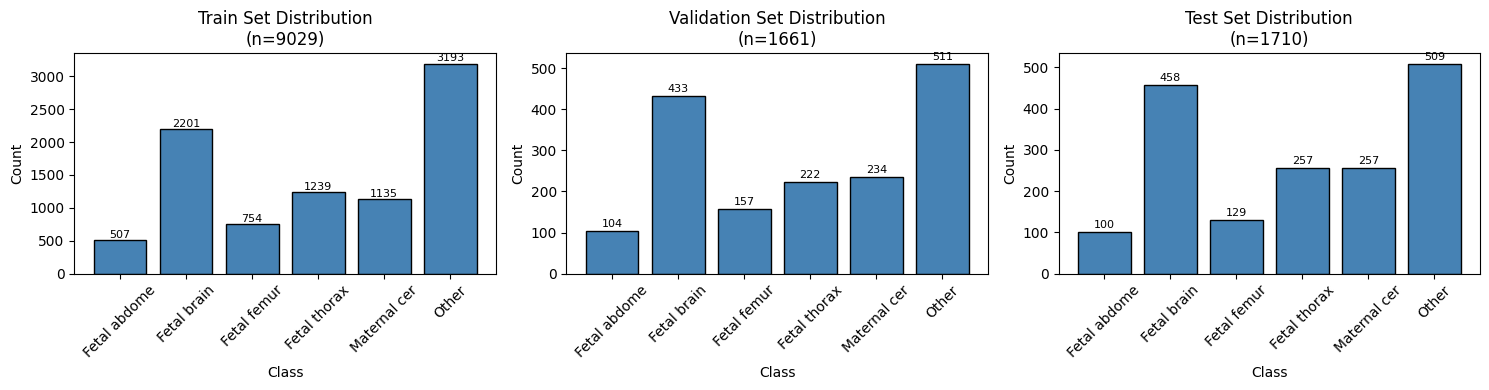

Saved: class_distribution.png


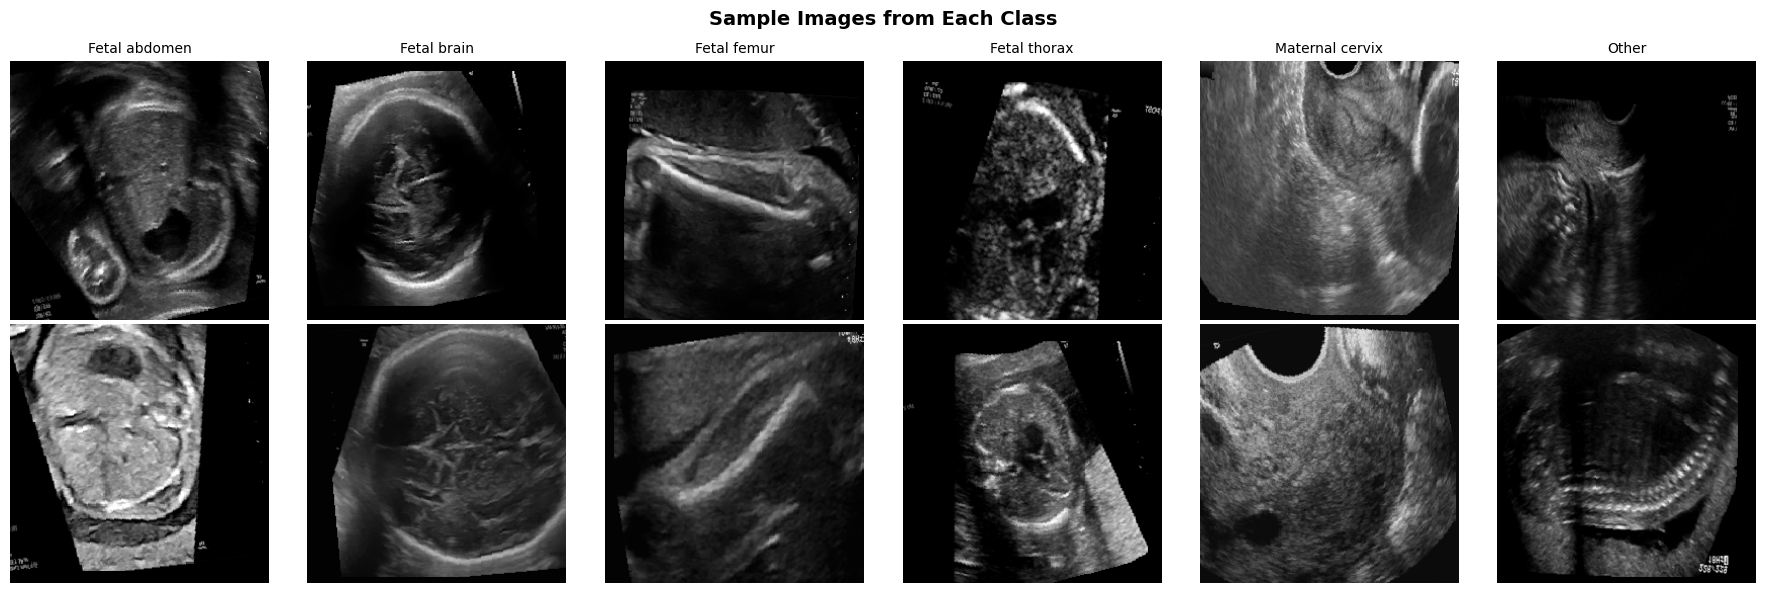

Saved: sample_images.png


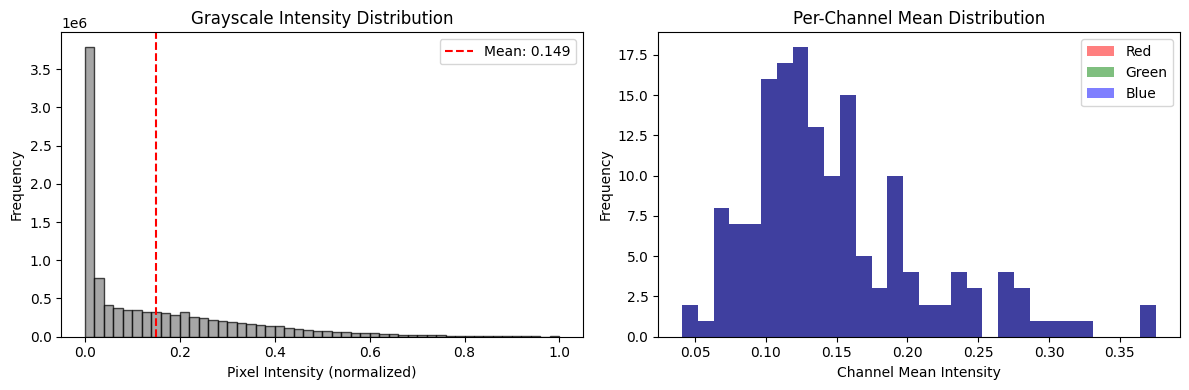

Saved: pixel_distribution.png

----------------------------------------
DATASET SUMMARY
----------------------------------------
Total images: 12400
  Train: 9029 (72.8%)
  Val:   1661 (13.4%)
  Test:  1710 (13.8%)

Number of classes: 6
Classes: ['Fetal abdomen', 'Fetal brain', 'Fetal femur', 'Fetal thorax', 'Maternal cervix', 'Other']
Image size: 256x256
Batch size: 16
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 350MB/s]

TRAINING BASELINE CLASSIFIER
Epoch 1/15: 100%|██████████| 565/565 [00:43<00:00, 13.11it/s, loss=0.5975, acc=84.10%]
Epoch 1: Train Acc: 84.10%, Val Acc: 89.22%
  --> Saved new best model (Val Acc: 89.22%)
Epoch 2/15: 100%|██████████| 565/565 [00:42<00:00, 13.33it/s, loss=0.5349, acc=86.28%]
Epoch 2: Train Acc: 86.28%, Val Acc: 88.44%
Epoch 3/15: 100%|██████████| 565/565 [00:42<00:00, 13.29it/s, loss=0.6941, acc=85.79%]
Epoch 3: Train Acc

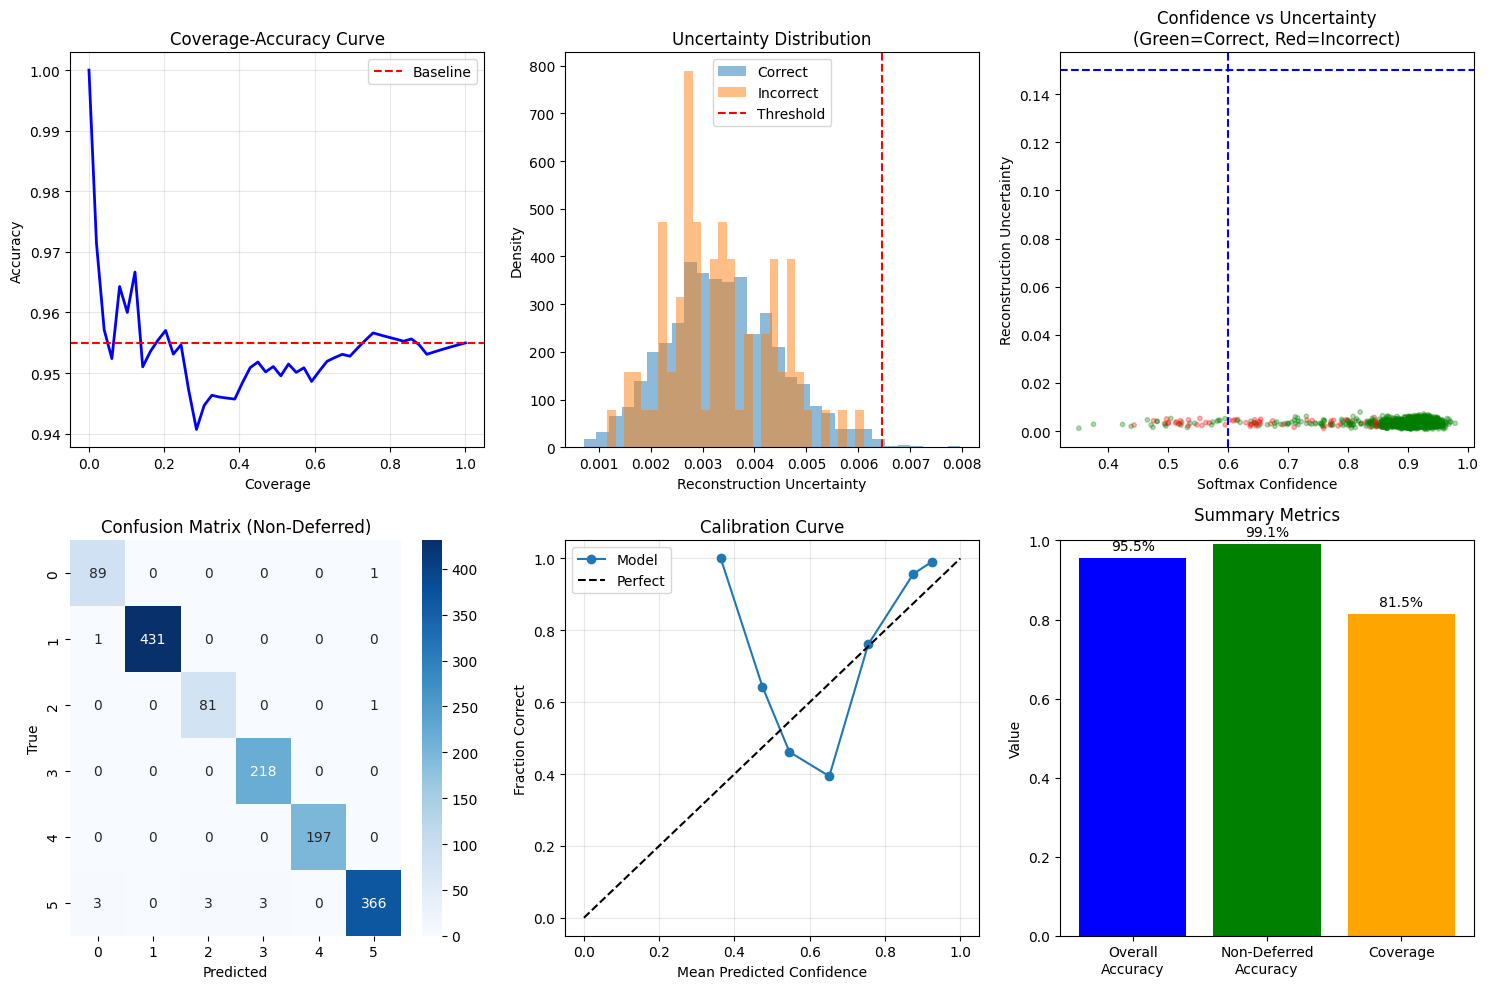

Saved visualization to /work/outputs/results_summary.png

Generating uncertainty visualization examples...


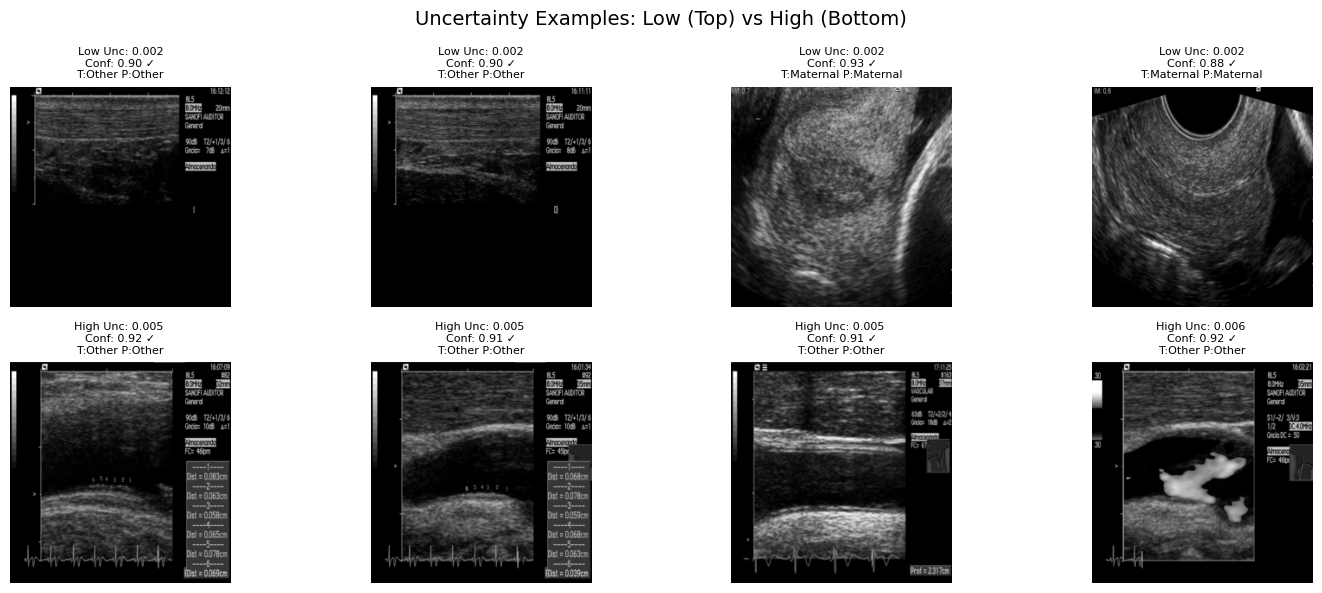


RUNNING EXTENDED ANALYSIS

COMPARING UNCERTAINTY METHODS
Comparing methods: 100%|██████████| 107/107 [00:39<00:00,  2.70it/s]


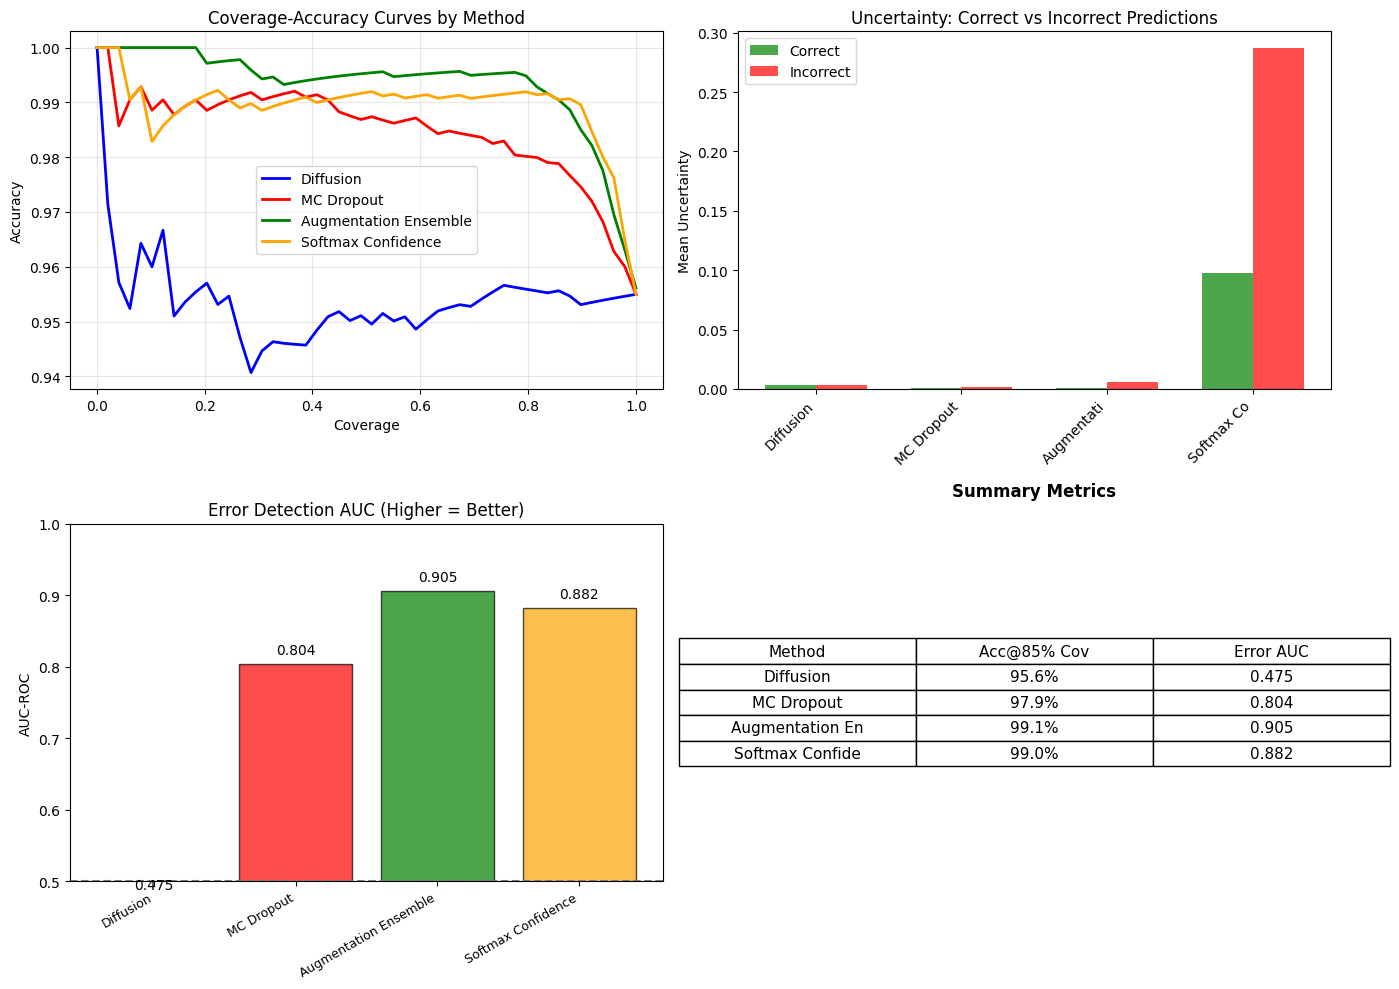

Saved: uncertainty_comparison.png

PER-CLASS DEFERRAL ANALYSIS


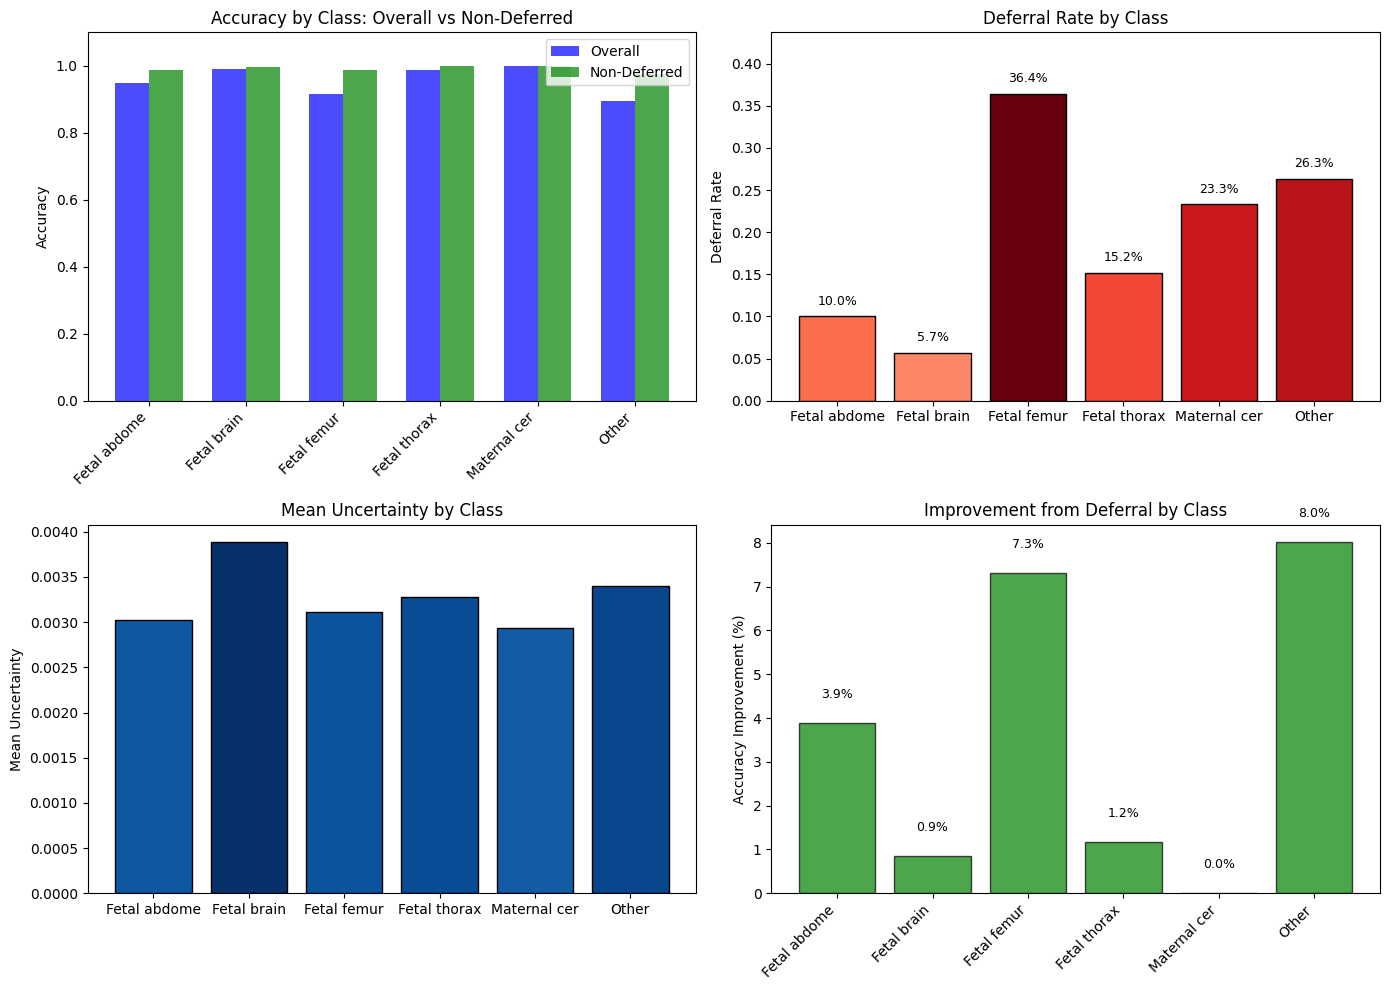

Saved: per_class_analysis.png

----------------------------------------------------------------------
Class                Total    Acc      NonDef Acc   Defer %    Improv  
----------------------------------------------------------------------
Fetal abdomen        100      95.0%    98.9%        10.0%      +3.9%
Fetal brain          458      98.9%    99.8%        5.7%      +0.9%
Fetal femur          129      91.5%    98.8%        36.4%      +7.3%
Fetal thorax         257      98.8%    100.0%        15.2%      +1.2%
Maternal cervix      257      100.0%    100.0%        23.3%      +0.0%
Other                509      89.6%    97.6%        26.3%      +8.0%

CLINICAL METRICS ANALYSIS


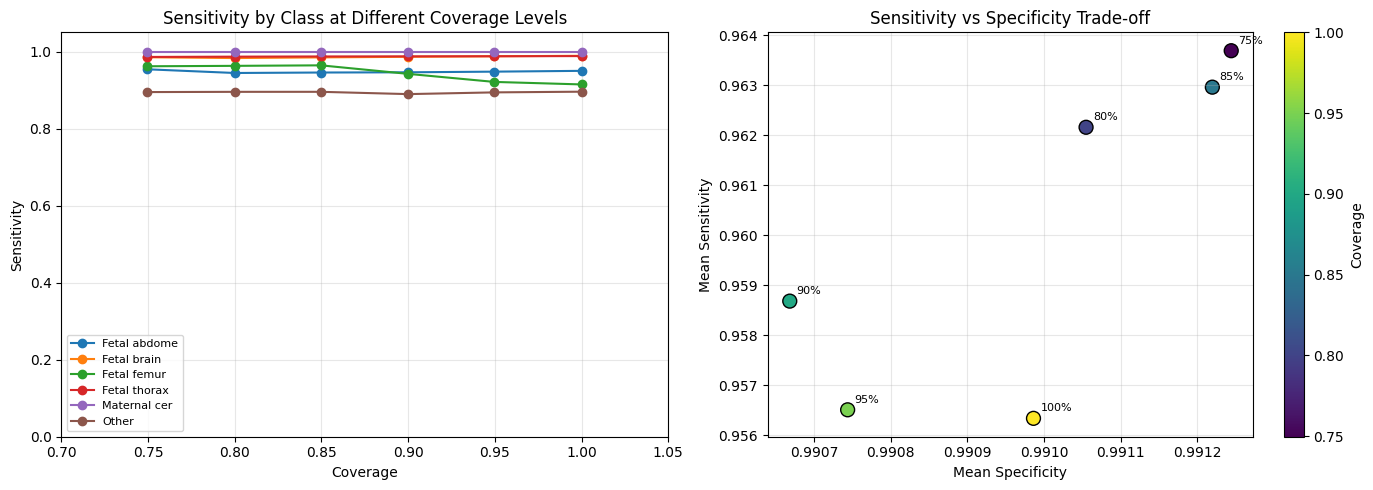

Saved: clinical_metrics.png

--------------------------------------------------------------------------------
Coverage     Accuracy     Mean Sens    Mean Spec   
--------------------------------------------------------------------------------
100.0%        95.5%        95.6%        99.1%
95.0%        95.4%        95.7%        99.1%
90.0%        95.3%        95.9%        99.1%
85.0%        95.6%        96.3%        99.1%
80.0%        95.5%        96.2%        99.1%
75.0%        95.6%        96.4%        99.1%

FEATURE SPACE VISUALIZATION (t-SNE)
Extracting features:  59%|█████▉    | 63/107 [00:04<00:03, 14.30it/s]
Running t-SNE on 1000 samples...


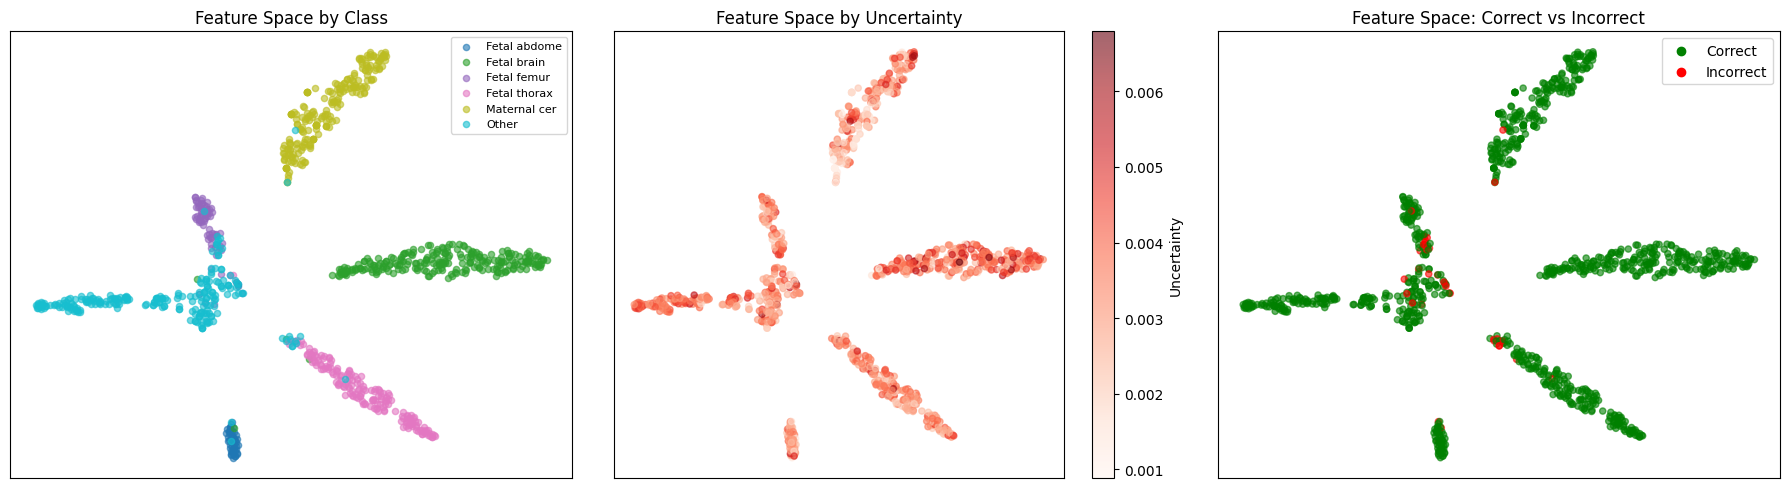

Saved: feature_space_tsne.png

ABLATION STUDY: DIFFUSION PARAMETERS
Running ablation on 160 images...
Ablation configs: 100%|██████████| 6/6 [1:23:30<00:00, 835.12s/it] 


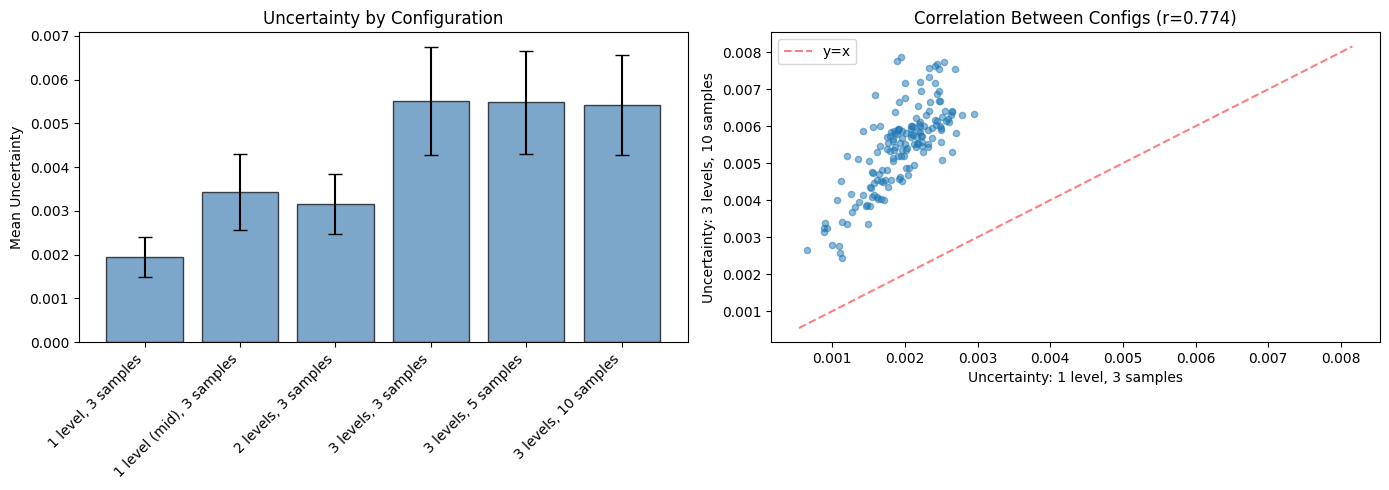

Saved: ablation_study.png

------------------------------------------------------------
Configuration                  Mean Unc     Std Unc     
------------------------------------------------------------
1 level, 3 samples             0.0019       0.0005
1 level (mid), 3 samples       0.0034       0.0009
2 levels, 3 samples            0.0031       0.0007
3 levels, 3 samples            0.0055       0.0012
3 levels, 5 samples            0.0055       0.0012
3 levels, 10 samples           0.0054       0.0011

OUT-OF-DISTRIBUTION DETECTION ANALYSIS
Evaluating OOD: 100%|██████████| 11/11 [01:27<00:00,  7.92s/it]


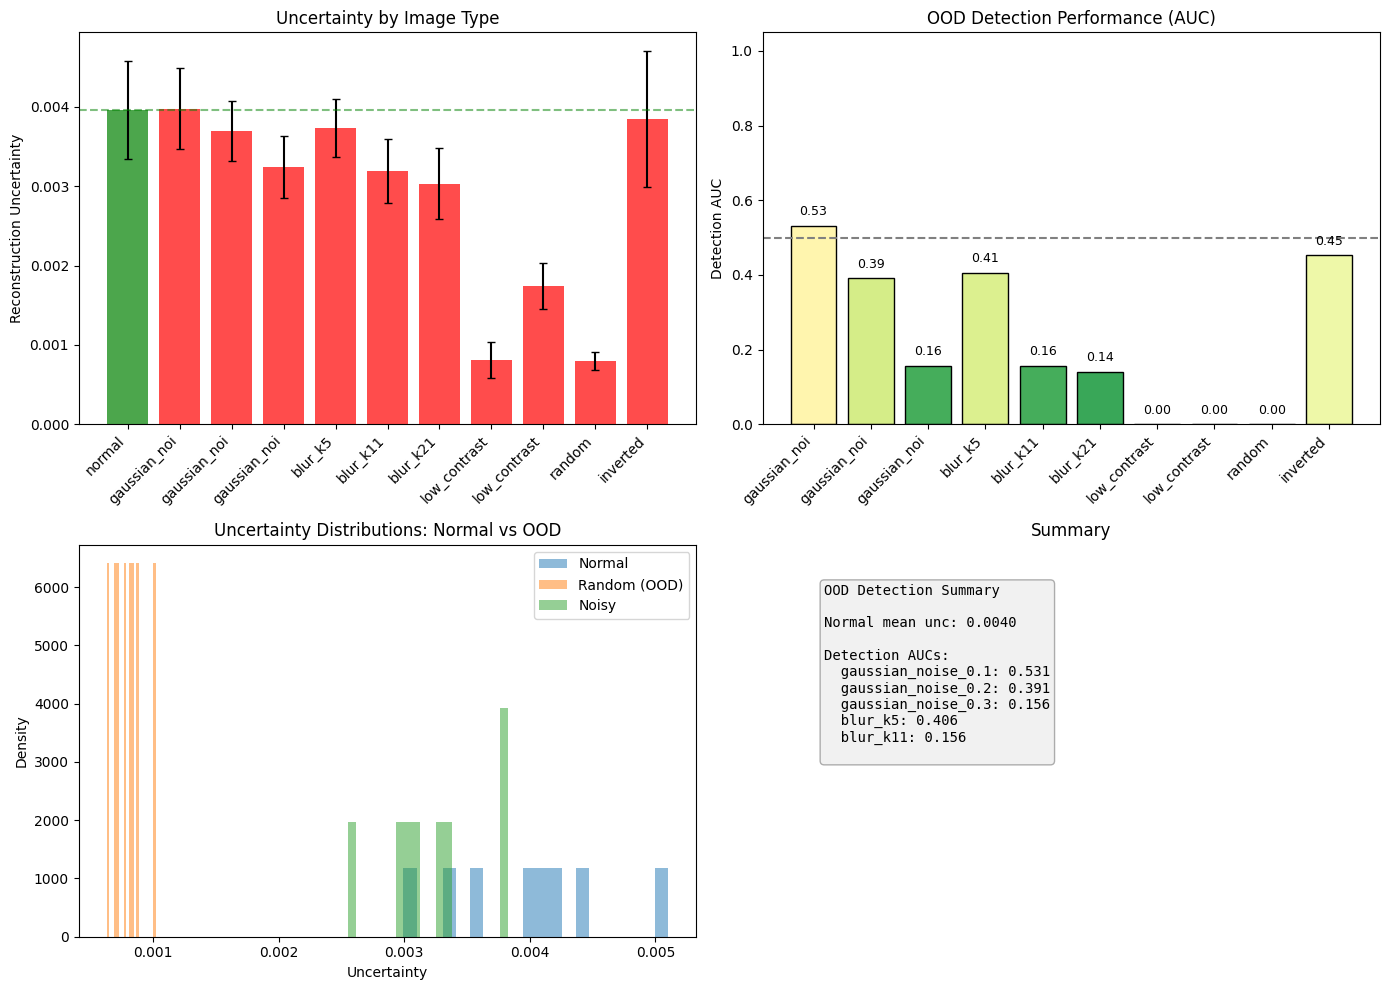

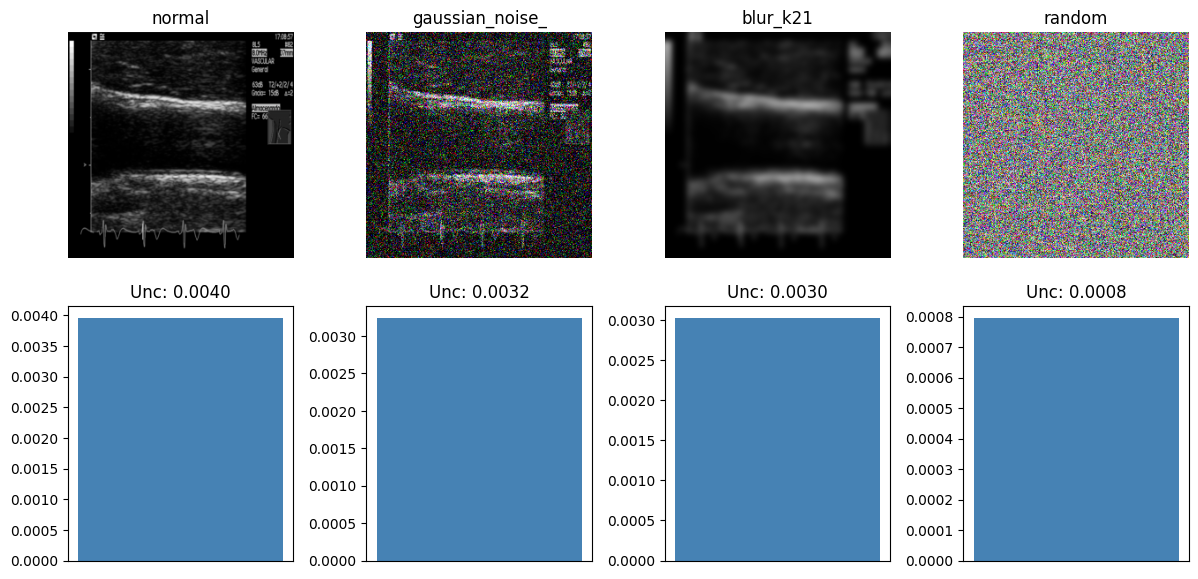


--------------------------------------------------
OOD DETECTION SUMMARY
--------------------------------------------------
Corruption Type           Mean Unc     Detection AUC
--------------------------------------------------
normal                    0.0040       ---         
gaussian_noise_0.1        0.0040       0.531
gaussian_noise_0.2        0.0037       0.391
gaussian_noise_0.3        0.0032       0.156
blur_k5                   0.0037       0.406
blur_k11                  0.0032       0.156
blur_k21                  0.0030       0.141
low_contrast_0.3          0.0008       0.000
low_contrast_0.5          0.0017       0.000
random                    0.0008       0.000
inverted                  0.0038       0.453

CLINICAL DEPLOYMENT SIMULATION


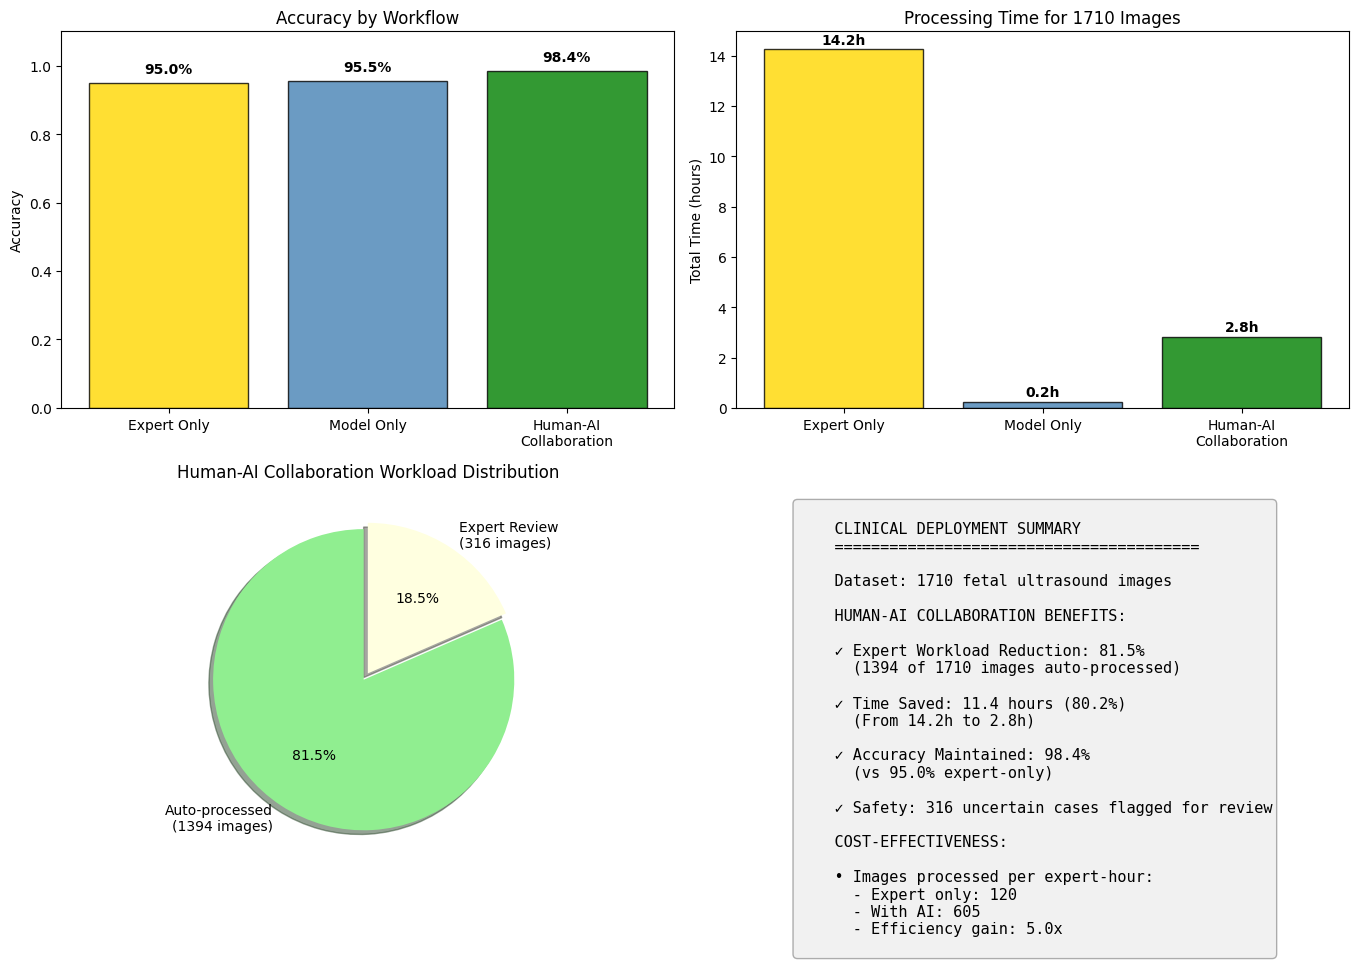


DEPLOYMENT METRICS
Expert workload reduction: 81.5%
Time saved: 80.2%
Collaboration accuracy: 98.4%
Uncertain cases flagged: 316 (18.5%)

EXTENDED ANALYSIS COMPLETE

EXPERIMENT COMPLETE!

Outputs saved to: /work/outputs
Models saved to: /work/models

Key Results:
  - Overall Accuracy: 95.50%
  - Accuracy with Deferral: 99.14%
  - Improvement: +3.64%


In [11]:
# Run experiment
if __name__ == "__main__":
    gated_classifier, test_results, metrics = main()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6902cf02-8be3-43ec-8bdb-9743d34fdb14' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>